# HouseTS: End-to-End Big Data ML Pipeline (SCALABLE VERSION)
## Spatiotemporal Housing Image Clustering — Apache Spark + MobileNetV2 + K-Means

---
# Stage 0 — Environment Setup

In [1]:
# !pip install pyspark findspark torch torchvision pillow scikit-learn
# !pip install matplotlib seaborn plotly pandas numpy tqdm

import os, sys, warnings, gc, json, glob
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Patch

import findspark
findspark.init()

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (
    StructType, StructField, StringType, FloatType,
    IntegerType, ArrayType, DoubleType
)
from pyspark.ml.feature import (
    VectorAssembler, StandardScaler, PCA as SparkPCA,
    StringIndexer, OneHotEncoder
)
from pyspark.ml.clustering import KMeans, BisectingKMeans
from pyspark.ml.evaluation import ClusteringEvaluator
from pyspark.ml import Pipeline

from pyspark.sql.functions import pandas_udf, col
from pyspark.sql.functions import PandasUDFType

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.models as models
from PIL import Image
from torch.utils.data import Dataset, DataLoader

from sklearn.decomposition import PCA as SklearnPCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler as SklearnScaler

from tqdm import tqdm

print(f"All imports successful.")
print(f"Python: {sys.version.split()[0]} | PyTorch: {torch.__version__}")

All imports successful.
Python: 3.11.15 | PyTorch: 2.12.0


In [2]:
# ─── Spark Session ────────────────────────────────────────────────────────────
spark = (
    SparkSession.builder
    .appName("HouseTS_Spatiotemporal_Clustering")
    .master("local[*]")
    .config("spark.driver.memory", "10g")
    .config("spark.executor.memory", "10g")
    .config("spark.driver.maxResultSize", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.default.parallelism", "8")
    .config("spark.sql.adaptive.enabled", "true")
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true")
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryoserializer.buffer.max", "512m")
    .config("spark.local.dir", "/tmp/spark_tmp")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

print(f"   SparkSession initialized")
print(f"   Spark version : {spark.version}")
print(f"   Master        : {spark.sparkContext.master}")
print(f"   Cores         : {spark.sparkContext.defaultParallelism}")

26/05/23 08:37:02 WARN Utils: Your hostname, Lizas-MacBook-Air.local resolves to a loopback address: 127.0.0.1; using 10.18.7.175 instead (on interface en0)
26/05/23 08:37:02 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/23 08:37:02 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/05/23 08:37:02 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


   SparkSession initialized
   Spark version : 3.5.1
   Master        : local[*]
   Cores         : 8


---
# Stage 1 — Data Preprocessing
## 1.0 Configuration

**Change the two paths below to match your local setup.  
Everything else adapts automatically.**

In [ ]:
# EDIT THESE TWO LINES to match your local paths
CSV_PATH   = "/path/to/HouseTS.csv"
IMAGE_ROOT = "/path/to/Housets_Final"

BATCH_SIZE       = 64
IMG_SIZE         = 128
N_PCA_COMPONENTS = 64
SAMPLE_FRACTION  = 1.0   # 0.10 = 10% for dev; set 1.0 for full run
RANDOM_SEED      = 42
MIN_IMAGES       = 100    # Pipeline will abort early if fewer real images are found

# ─── Validate paths immediately — fail fast with a clear message ───────────────
assert os.path.isfile(CSV_PATH), (
    f"   CSV not found: {CSV_PATH}\n"
    f"   Please update CSV_PATH in the config cell above."
)
assert os.path.isdir(IMAGE_ROOT), (
    f"   Image root not found: {IMAGE_ROOT}\n"
    f"   Please update IMAGE_ROOT in the config cell above."
)

# Count city subdirectories so we can verify the folder structure
city_dirs = [d for d in os.listdir(IMAGE_ROOT)
             if os.path.isdir(os.path.join(IMAGE_ROOT, d))]

print(f"   CSV found     : {CSV_PATH}")
print(f"   Image root    : {IMAGE_ROOT}")
print(f"   City folders  : {len(city_dirs)}")
print(f"   Cities found  : {city_dirs[:10]} {'...' if len(city_dirs) > 10 else ''}")

if len(city_dirs) == 0:
    raise RuntimeError(
        "IMAGE_ROOT exists but contains no subdirectories.\n"
        "Expected structure: IMAGE_ROOT/<city>/<zipcode>/*.png"
    )

   CSV found     : /Users/lizamarievaldez/Documents/PROJECT/HouseTS.csv
   Image root    : /Users/lizamarievaldez/Documents/PROJECT/Housets_Image/Housets_Final
   City folders  : 30
   Cities found  : ['New_York', 'Detroit', 'Austin', 'Riverside', 'Sacramento', 'Las_Vegas', 'Atlanta', 'Minneapolis', 'Seattle', 'Chicago'] ...


## 1.1 Load HouseTS.csv

In [4]:
df_raw = (
    spark.read
    .option("header", "true")
    .option("inferSchema", "true")
    .option("multiLine", "true")
    .option("escape", '"')
    .csv(CSV_PATH)
)

print(f"   Loaded HouseTS CSV")
print(f"   Rows       : {df_raw.count():,}")
print(f"   Columns    : {len(df_raw.columns)}")
print(f"   Partitions : {df_raw.rdd.getNumPartitions()}")
df_raw.printSchema()

   Loaded HouseTS CSV
   Rows       : 884,092
   Columns    : 39
   Partitions : 1
root
 |-- date: date (nullable = true)
 |-- median_sale_price: double (nullable = true)
 |-- median_list_price: double (nullable = true)
 |-- median_ppsf: double (nullable = true)
 |-- median_list_ppsf: double (nullable = true)
 |-- homes_sold: double (nullable = true)
 |-- pending_sales: double (nullable = true)
 |-- new_listings: double (nullable = true)
 |-- inventory: double (nullable = true)
 |-- median_dom: double (nullable = true)
 |-- avg_sale_to_list: double (nullable = true)
 |-- sold_above_list: double (nullable = true)
 |-- off_market_in_two_weeks: double (nullable = true)
 |-- city: string (nullable = true)
 |-- zipcode: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- bank: double (nullable = true)
 |-- bus: double (nullable = true)
 |-- hospital: double (nullable = true)
 |-- mall: double (nullable = true)
 |-- park: double (nullable = true)
 |-- restaurant: double (null

## 1.2 Missing Value Analysis & Data Cleaning

In [5]:
NUM_COLS = [
    "median_sale_price", "median_list_price", "median_ppsf", "median_list_ppsf",
    "homes_sold", "pending_sales", "new_listings", "inventory", "median_dom",
    "avg_sale_to_list", "sold_above_list", "off_market_in_two_weeks",
    "Total Population", "Median Age", "Per Capita Income",
    "Total Families Below Poverty", "Total Housing Units", "Median Rent",
    "Median Home Value", "Total Labor Force", "Unemployed Population",
    "Total School Age Population", "Total School Enrollment",
    "Median Commute Time", "price"
]

medians = {
    c: df_raw.approxQuantile(c, [0.5], 0.01)[0]
    for c in NUM_COLS if c in df_raw.columns
}

df_clean = df_raw
for col_name, med_val in medians.items():
    if med_val is not None:
        df_clean = df_clean.withColumn(
            col_name,
            F.when(F.col(col_name).isNull(), med_val).otherwise(F.col(col_name))
        )

for col_name in ["city", "zipcode", "city_full"]:
    if col_name in df_clean.columns:
        df_clean = df_clean.fillna("Unknown", subset=[col_name])

before = df_clean.count()
df_clean = df_clean.dropDuplicates()
after = df_clean.count()

print(f" Cleaning complete | Rows: {before:,} → {after:,} (removed {before-after:,} duplicates)")

 Cleaning complete | Rows: 884,092 → 884,092 (removed 0 duplicates)


In [6]:
# ─── Temporal features & derived columns ──────────────────────────────────────
df_clean = (
    df_clean
    .withColumn("date_parsed", F.to_date(F.col("date"), "yyyy-MM-dd"))
    .withColumn("year_parsed", F.year("date_parsed"))
    .withColumn("month",       F.month("date_parsed"))
    .withColumn("quarter",     F.quarter("date_parsed"))
    .withColumn("day_of_week", F.dayofweek("date_parsed"))
)

df_clean = df_clean.withColumn(
    "affordability_ratio",
    F.when(F.col("Per Capita Income") > 0,
           F.col("median_sale_price") / F.col("Per Capita Income")).otherwise(None)
)
df_clean = df_clean.withColumn(
    "price_to_rent_ratio",
    F.when(F.col("Median Rent") > 0,
           F.col("median_sale_price") / (F.col("Median Rent") * 12)).otherwise(None)
)
df_clean = df_clean.withColumn(
    "unemployment_rate",
    F.when(F.col("Total Labor Force") > 0,
           F.col("Unemployed Population") / F.col("Total Labor Force") * 100).otherwise(None)
)
df_clean = df_clean.withColumn(
    "school_enrollment_rate",
    F.when(F.col("Total School Age Population") > 0,
           F.col("Total School Enrollment") / F.col("Total School Age Population") * 100).otherwise(None)
)

amenity_cols = ["bank", "bus", "hospital", "mall", "park", "restaurant", "school", "station", "supermarket"]
amenity_expr = sum(F.col(c) for c in amenity_cols if c in df_clean.columns)
df_clean = df_clean.withColumn("amenity_score", amenity_expr)

df_clean = df_clean.repartition(8).cache()
df_clean.count()  # Trigger caching

print(" Feature engineering complete")

 Feature engineering complete


---
# Stage 2 — EDA

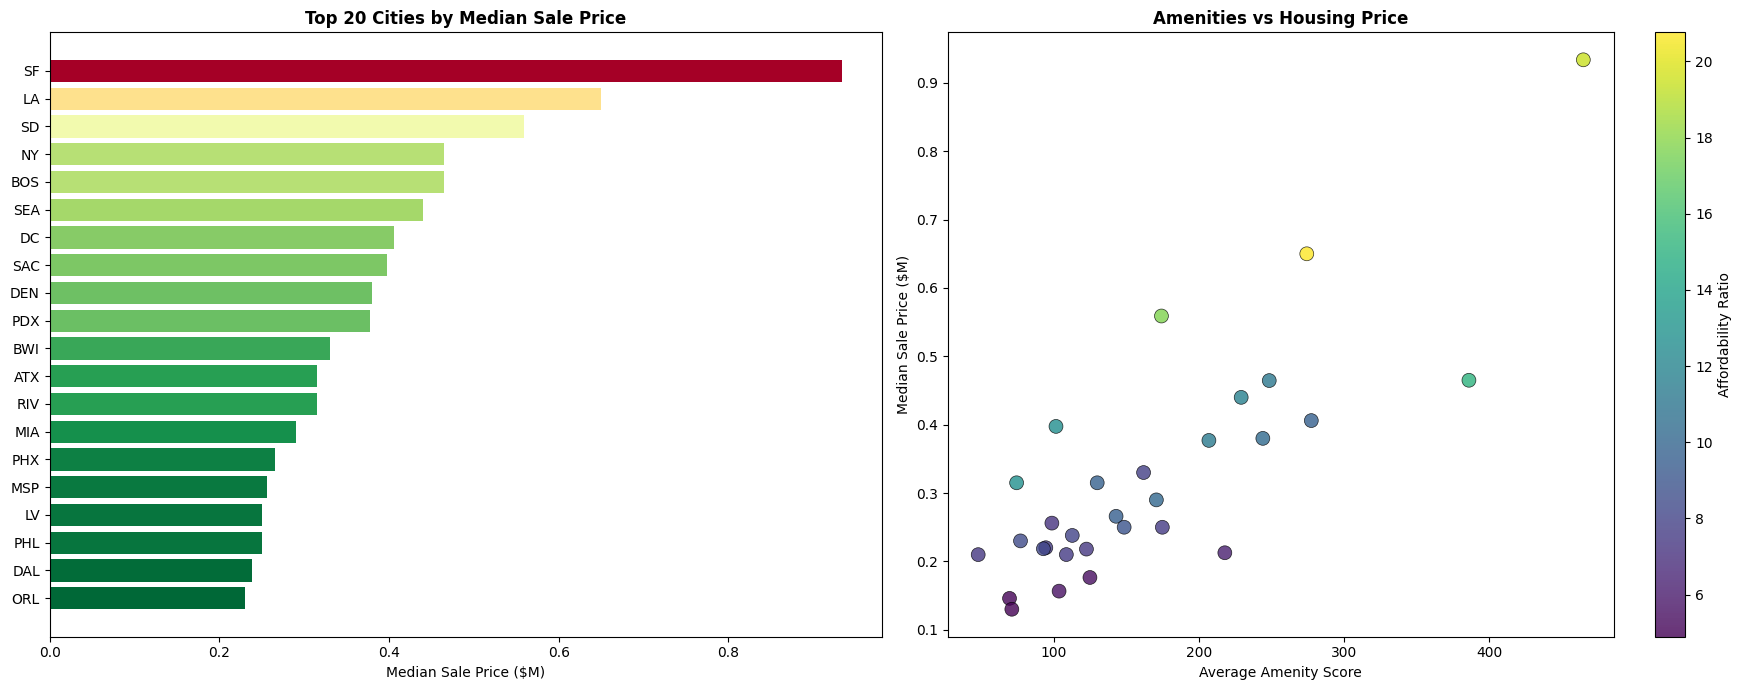

In [7]:
# City-level price aggregates
city_prices = (
    df_clean
    .groupBy("city")
    .agg(
        F.median("median_sale_price").alias("median_price"),
        F.count("*").alias("record_count"),
        F.avg("affordability_ratio").alias("avg_affordability"),
        F.avg("amenity_score").alias("avg_amenities")
    )
    .orderBy(F.desc("median_price"))
    .limit(30)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
top20 = city_prices.head(20)
axes[0].barh(top20["city"], top20["median_price"] / 1e6,
             color=plt.cm.RdYlGn_r(
                 (top20["median_price"] - top20["median_price"].min()) /
                 (top20["median_price"].max() - top20["median_price"].min())
             ))
axes[0].set_xlabel("Median Sale Price ($M)")
axes[0].set_title("Top 20 Cities by Median Sale Price", fontweight="bold")
axes[0].invert_yaxis()

scatter = axes[1].scatter(
    city_prices["avg_amenities"], city_prices["median_price"] / 1e6,
    c=city_prices["avg_affordability"], cmap="viridis", s=100, alpha=0.8,
    edgecolors="k", linewidths=0.5
)
plt.colorbar(scatter, ax=axes[1], label="Affordability Ratio")
axes[1].set_xlabel("Average Amenity Score")
axes[1].set_ylabel("Median Sale Price ($M)")
axes[1].set_title("Amenities vs Housing Price", fontweight="bold")

plt.tight_layout()
plt.savefig("eda_city_prices.png", dpi=120, bbox_inches="tight")
plt.show()

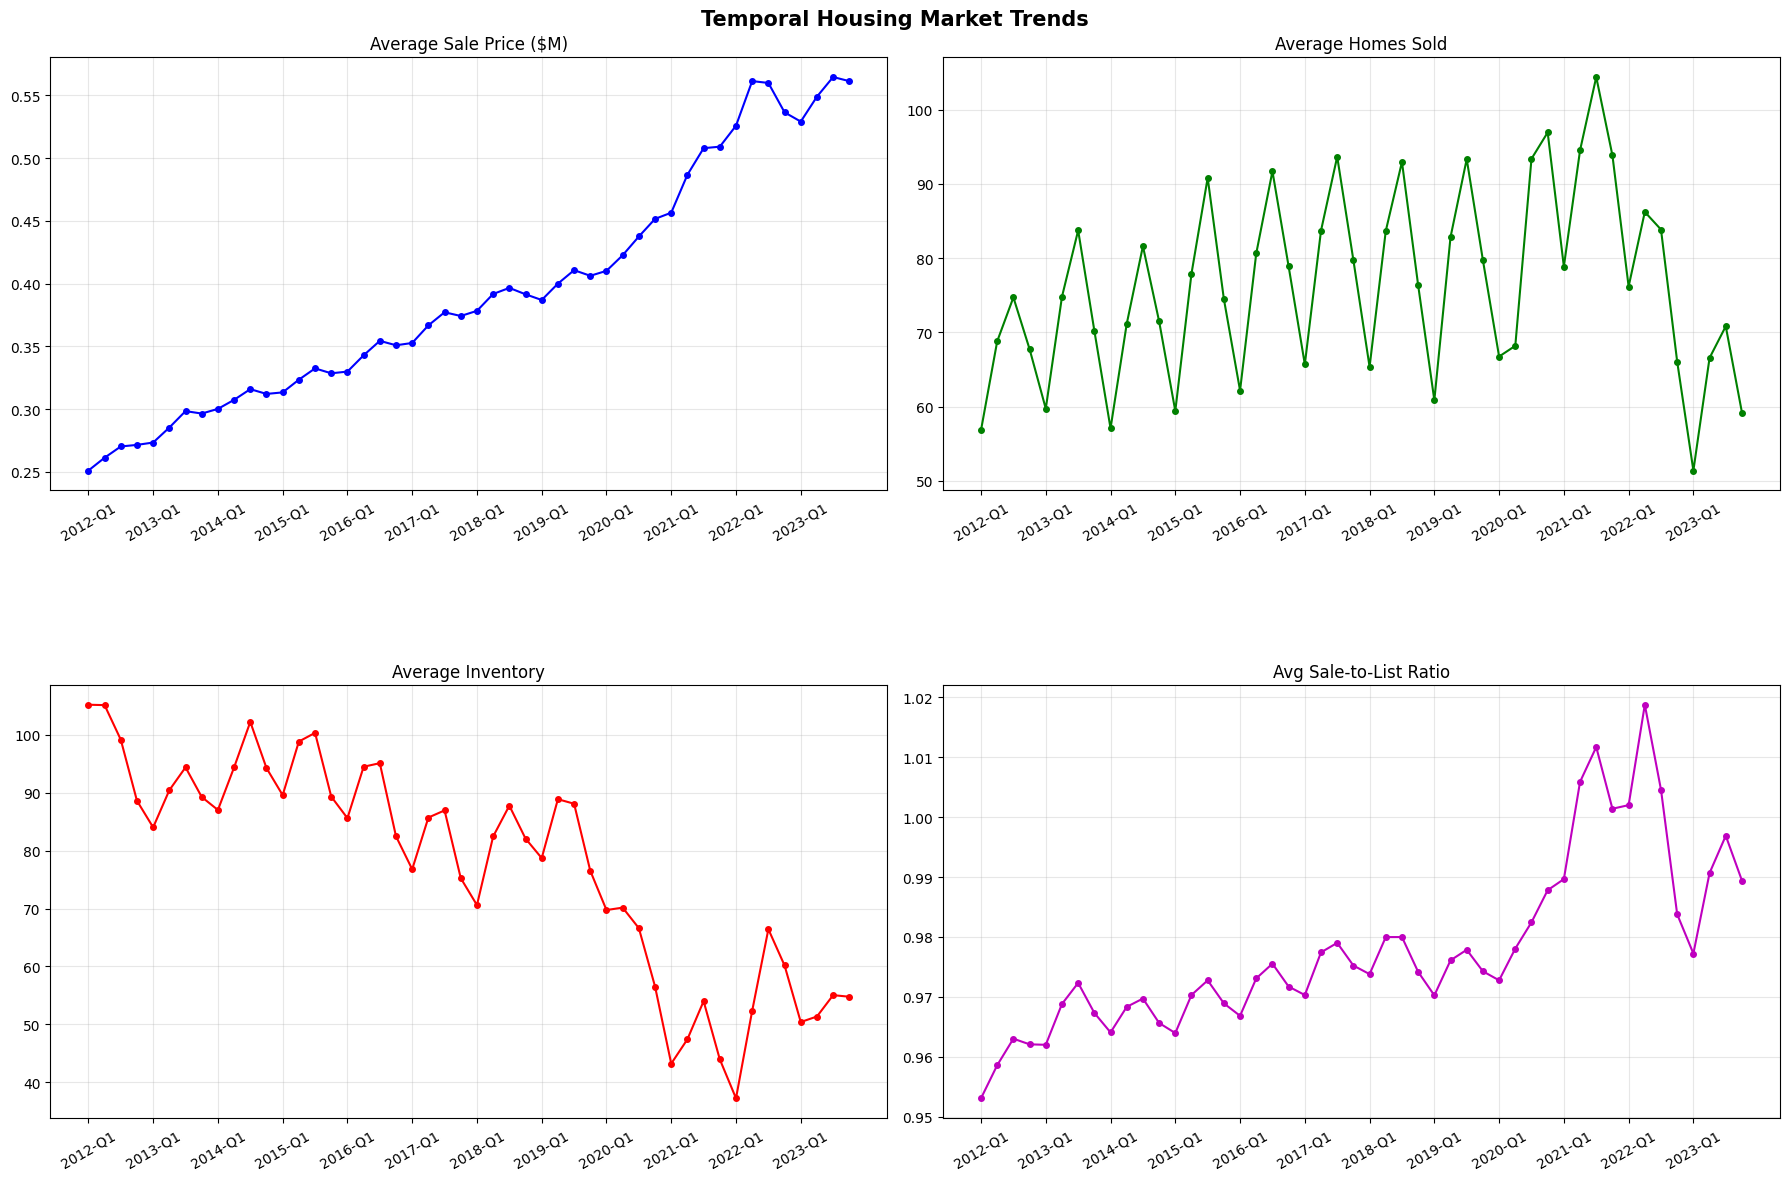

In [8]:
# Temporal trend
temporal = (
    df_clean
    .groupBy("year_parsed", "quarter")
    .agg(
        F.avg("median_sale_price").alias("avg_sale_price"),
        F.avg("homes_sold").alias("avg_homes_sold"),
        F.avg("inventory").alias("avg_inventory"),
        F.avg("avg_sale_to_list").alias("avg_sale_to_list")
    )
    .orderBy("year_parsed", "quarter")
    .toPandas()
)

# Create period label
temporal["period"] = (
    temporal["year_parsed"].astype(str)
    + "-Q"
    + temporal["quarter"].astype(str)
)

# Create plots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle("Temporal Housing Market Trends", fontsize=15, fontweight="bold")

for ax, col, title, color in zip(
    axes.flat,
    ["avg_sale_price", "avg_homes_sold", "avg_inventory", "avg_sale_to_list"],
    ["Average Sale Price ($M)", "Average Homes Sold", "Average Inventory", "Avg Sale-to-List Ratio"],
    ["b", "g", "r", "m"]
):

    # Convert sale price to millions
    data = temporal[col] / 1e6 if col == "avg_sale_price" else temporal[col]

    # Plot line
    ax.plot(temporal["period"], data, f"{color}-o", markersize=4)

    # Titles
    ax.set_title(title)

    # Show fewer x-axis labels (every 4 quarters = yearly)
    ax.set_xticks(range(0, len(temporal["period"]), 4))
    ax.set_xticklabels(temporal["period"][::4], rotation=30)

    # Grid
    ax.grid(alpha=0.3)

# Improve spacing between subplots
plt.tight_layout()
plt.subplots_adjust(hspace=0.45)

# Save and show
plt.savefig("eda_temporal_trends.png", dpi=120, bbox_inches="tight")
plt.show()

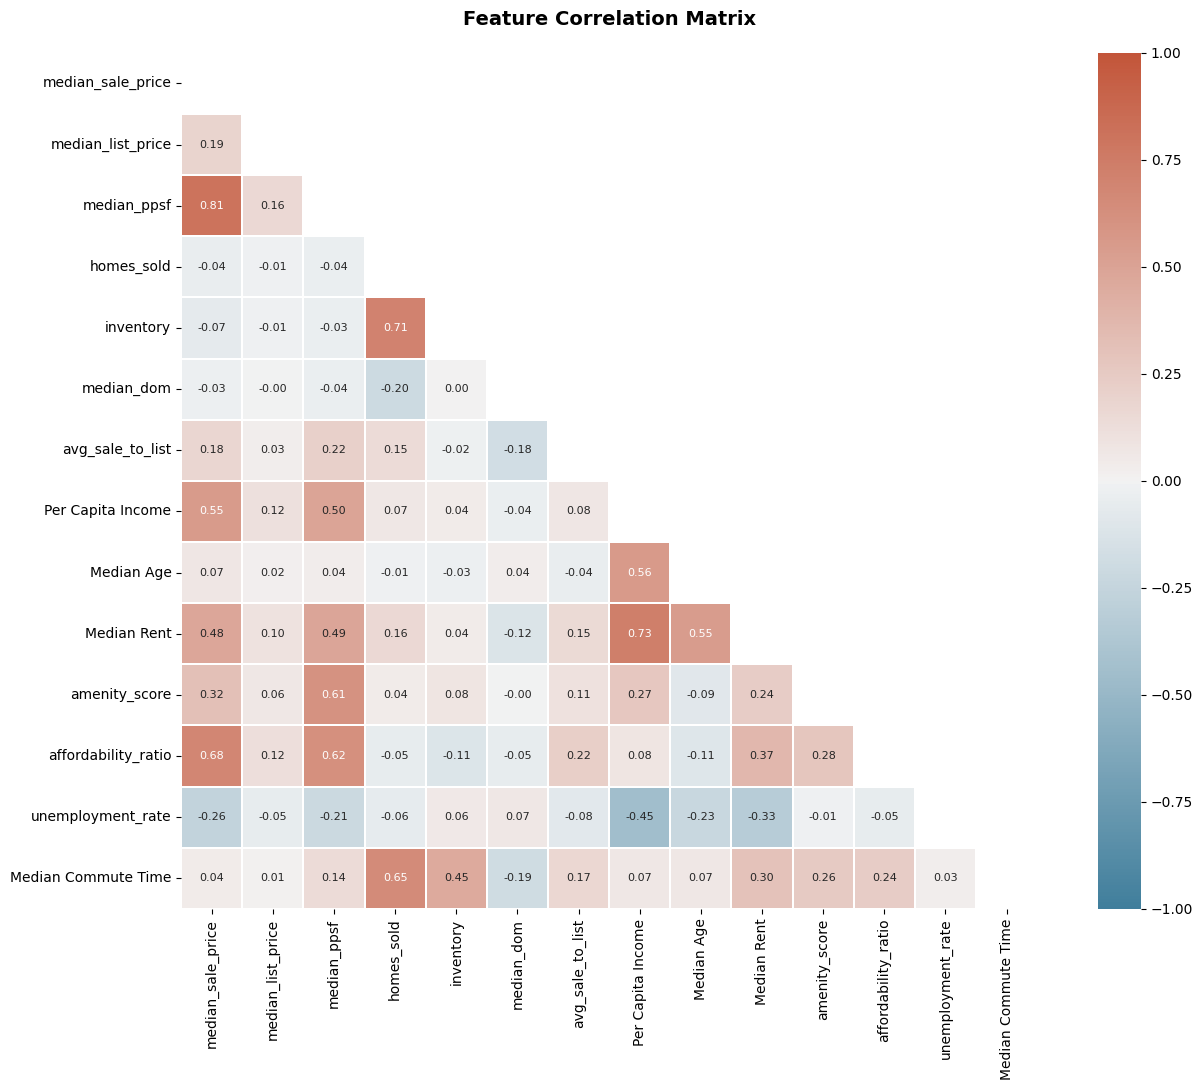

In [9]:
# Correlation heatmap
CORR_COLS = [
    "median_sale_price", "median_list_price", "median_ppsf",
    "homes_sold", "inventory", "median_dom", "avg_sale_to_list",
    "Per Capita Income", "Median Age", "Median Rent", "amenity_score",
    "affordability_ratio", "unemployment_rate", "Median Commute Time"
]
corr_sample = df_clean.select(CORR_COLS).sample(fraction=0.3, seed=RANDOM_SEED).toPandas()
corr_matrix = corr_sample.corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_matrix, mask=mask, cmap=sns.diverging_palette(230, 20, as_cmap=True),
            vmax=1, vmin=-1, center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, square=True, linewidths=0.3, ax=ax)
ax.set_title("Feature Correlation Matrix", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("eda_correlation.png", dpi=120, bbox_inches="tight")
plt.show()

---
# Stage 3 — Feature Engineering
## 3.1 Image Catalog

In [10]:
pattern = os.path.join(IMAGE_ROOT, "*", "*", "*.png")
all_png_paths = sorted(glob.glob(pattern))

print(f"Glob pattern : {pattern}")
print(f"PNGs found   : {len(all_png_paths):,}")

if len(all_png_paths) == 0:
    # Try one level deeper in case the folder nesting is different
    alt_pattern = os.path.join(IMAGE_ROOT, "*", "*.png")
    alt_paths   = sorted(glob.glob(alt_pattern))
    print(f"\nTried alternate pattern: {alt_pattern}")
    print(f"PNGs found (2-level)   : {len(alt_paths):,}")
    if len(alt_paths) > 0:
        all_png_paths = alt_paths
        print("Using 2-level pattern.")
    else:
        raise FileNotFoundError(
            f"No PNG files found under {IMAGE_ROOT}.\n"
            f"Tried 3-level: {pattern}\n"
            f"Tried 2-level: {alt_pattern}\n"
            f"Please check IMAGE_ROOT and your folder structure."
        )

# Build metadata rows from path components
manifest_rows = []
for p in all_png_paths:
    parts     = p.split(os.sep)
    filename  = parts[-1]
    zipcode   = parts[-2] if len(parts) >= 2 else "unknown"
    city_dir  = parts[-3] if len(parts) >= 3 else "unknown"
    manifest_rows.append((p, city_dir, zipcode, filename))

from pyspark.sql.types import StructType, StructField, StringType

schema_manifest = StructType([
    StructField("image_path",  StringType(), False),
    StructField("city",        StringType(), True),
    StructField("zipcode_id",  StringType(), True),
    StructField("filename",    StringType(), True),
])

df_images = spark.createDataFrame(manifest_rows, schema=schema_manifest)

# Apply sample fraction
if SAMPLE_FRACTION < 1.0:
    df_images = df_images.sample(fraction=SAMPLE_FRACTION, seed=RANDOM_SEED)
    print(f"Sampling {SAMPLE_FRACTION*100:.0f}% of images.")

df_images = df_images.repartition(8).cache()
total_images = df_images.count()
total_cities = df_images.select("city").distinct().count()

print(f"\n Manifest ready: {total_images:,} images across {total_cities} city folders")
df_images.show(5, truncate=False)

# Quick sanity-check: verify the first path is actually openable by PIL
sample_path = df_images.select("image_path").first()[0]
try:
    test_img = Image.open(sample_path).convert("RGB")
    print(f" PIL sanity check passed — first image opened: {sample_path}")
    print(f"   Size: {test_img.size}  Mode: {test_img.mode}")
except Exception as e:
    raise RuntimeError(
        f"PIL cannot open the first sampled image.\n"
        f"Path: {sample_path}\nError: {e}\n"
        f"Check file permissions and that the images are valid PNGs."
    )

Glob pattern : /Users/lizamarievaldez/Documents/PROJECT/Housets_Image/Housets_Final/*/*/*.png
PNGs found   : 35,099

 Manifest ready: 35,099 images across 30 city folders
+---------------------------------------------------------------------------------------------------+---------+----------+--------------+
|image_path                                                                                         |city     |zipcode_id|filename      |
+---------------------------------------------------------------------------------------------------+---------+----------+--------------+
|/Users/lizamarievaldez/Documents/PROJECT/Housets_Image/Housets_Final/Baltimore/21794/21794_2017.png|Baltimore|21794     |21794_2017.png|
|/Users/lizamarievaldez/Documents/PROJECT/Housets_Image/Housets_Final/Baltimore/21617/21617_2023.png|Baltimore|21617     |21617_2023.png|
|/Users/lizamarievaldez/Documents/PROJECT/Housets_Image/Housets_Final/Atlanta/30135/30135_2013.png  |Atlanta  |30135     |30135_2013.png|
|

## 3.2 Broadcasted MobileNetV2 Feature Extraction

In [11]:
# DISTRIBUTED FEATURE EXTRACTION - With embedded class definition

# Step 1: Optimize partitioning
total_images = df_images.count()
print(f"\n📊 Total images to process: {total_images:,}")
print(f"   Original partitions: {df_images.rdd.getNumPartitions()}")

# More partitions for memory safety
optimal_partitions = max(16, (total_images // 200))
df_images = df_images.repartition(optimal_partitions)
print(f"   Optimized partitions: {df_images.rdd.getNumPartitions()} (~{total_images//optimal_partitions} images/partition)")

# Step 2: Define pandas UDF with class definition INSIDE
@pandas_udf(ArrayType(FloatType()), PandasUDFType.SCALAR)
def extract_features_udf(image_paths: pd.Series) -> pd.Series:
    """Pandas UDF that extracts features from image paths in parallel.
    
    The MobileNet extractor class is defined INSIDE this function so it
    gets properly serialized and sent to all executors.
    """
    import torch
    import torch.nn as nn
    import torchvision.models as models
    import torchvision.transforms as transforms
    from PIL import Image
    import numpy as np
    
    # Define the extractor class INSIDE the UDF
    class MobileNetExtractor:
        def __init__(self, img_size=128):
            self.img_size = img_size
            self.device = "cuda" if torch.cuda.is_available() else "cpu"
            
            # Load MobileNetV2 without classifier
            base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
            self.model = nn.Sequential(*list(base.children())[:-1], nn.AdaptiveAvgPool2d(1))
            self.model.eval()
            self.model.to(self.device)
            
            # Image preprocessing
            self.transform = transforms.Compose([
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                   std=[0.229, 0.224, 0.225])
            ])
        
        def extract_single(self, path):
            """Extract features from a single image."""
            try:
                img = Image.open(path).convert("RGB")
                tensor = self.transform(img).unsqueeze(0).to(self.device)
                
                with torch.no_grad():
                    features = self.model(tensor).squeeze(-1).squeeze(-1).cpu().numpy()
                
                return features[0]
            except Exception as e:
                # Return zeros on error
                return np.zeros(1280, dtype=np.float32)
    
    # Create ONE extractor instance per partition (reused for all images in partition)
    extractor = MobileNetExtractor(img_size=IMG_SIZE)
    
    def process_single_image(path):
        try:
            features = extractor.extract_single(path)
            return features.tolist()
        except Exception as e:
            return np.zeros(1280, dtype=np.float32).tolist()
    
    return image_paths.apply(process_single_image)

# Step 3: Apply distributed extraction
print(f"\n⚡ Starting DISTRIBUTED feature extraction...")
print(f"   Processing across {spark.sparkContext.defaultParallelism} cores")
print(f"   Each executor will load MobileNetV2 once and reuse it")
print(f"   (This may take 5-15 minutes for 35K images)\n")

df_with_features = df_images.withColumn(
    "raw_features_array",
    extract_features_udf(F.col("image_path"))
)

# Step 4: Convert to vectors
from pyspark.ml.linalg import Vectors, VectorUDT

def array_to_vector_udf(arr):
    """Convert array to DenseVector, filter zeros."""
    if arr and sum(arr) != 0:
        return Vectors.dense(arr)
    else:
        return None

array_to_vector = F.udf(array_to_vector_udf, VectorUDT())

df_with_vectors = (
    df_with_features
    .withColumn("raw_features", array_to_vector(F.col("raw_features_array")))
    .select("city", "zipcode_id", "image_path", "raw_features")
)

# Step 5: Filter nulls and cache
df_embeddings_valid = df_with_vectors.filter(F.col("raw_features").isNotNull()).cache()

# Step 6: Verify results
print("🔄 Executing distributed processing...")
n_valid = df_embeddings_valid.count()
n_skipped = total_images - n_valid

print(f"\n DISTRIBUTED feature extraction complete!")
print(f"   Images attempted     : {total_images:,}")
print(f"   Embeddings produced  : {n_valid:,}")
print(f"   Skipped/corrupted    : {n_skipped:,}")
print(f"   Success rate         : {n_valid/total_images*100:.1f}%")
print(f"   Embedding dimensions : 1280")
print(f"   Processing mode      : DISTRIBUTED\n")

# Validation
if n_valid == 0:
    raise RuntimeError(
        f" FATAL: No valid embeddings from {total_images:,} images.\n"
        "Check image paths and PyTorch installation."
    )

if n_valid < 100:
    print(f"  WARNING: Only {n_valid} embeddings. Quality may be poor.")

df_embeddings_valid.show(3, truncate=True)


📊 Total images to process: 35,099
   Original partitions: 8
   Optimized partitions: 175 (~200 images/partition)

⚡ Starting DISTRIBUTED feature extraction...
   Processing across 8 cores
   Each executor will load MobileNetV2 once and reuse it
   (This may take 5-15 minutes for 35K images)

🔄 Executing distributed processing...

 DISTRIBUTED feature extraction complete!
   Images attempted     : 35,099
   Embeddings produced  : 35,099
   Skipped/corrupted    : 0
   Success rate         : 100.0%
   Embedding dimensions : 1280
   Processing mode      : DISTRIBUTED

+------------+----------+--------------------+--------------------+
|        city|zipcode_id|          image_path|        raw_features|
+------------+----------+--------------------+--------------------+
|     Chicago|     60169|/Users/lizamariev...|[0.03353527560830...|
|Philadelphia|     19401|/Users/lizamariev...|[0.0,0.0910963639...|
|          DC|     20024|/Users/lizamariev...|[1.77391695976257...|
+------------+------

## 3.3 PCA Dimensionality Reduction

In [12]:
# Prepare embeddings DataFrame for PCA and clustering

# The distributed extraction already created df_embeddings_valid with:
# - city, zipcode_id, raw_features (DenseVector)
# - Filtered to only valid (non-null) features
# - Cached for performance

# Rename for compatibility with downstream cells
df_embeddings = df_embeddings_valid.select(
    F.col("city"),
    F.col("zipcode_id"),
    F.col("raw_features")
).repartition(8).cache()

print(f" Embedding DataFrame prepared: {df_embeddings.count():,} rows")
df_embeddings.show(3, truncate=True)

 Embedding DataFrame prepared: 35,099 rows
+------------+----------+--------------------+
|        city|zipcode_id|        raw_features|
+------------+----------+--------------------+
|          DC|     20190|[0.0,0.0084545332...|
|     Houston|     77009|[0.03724686056375...|
|Philadelphia|     19382|[0.22590145468711...|
+------------+----------+--------------------+
only showing top 3 rows



 Features standardized
 PCA: 1280 → 64 dims
   Variance retained: 65.8%


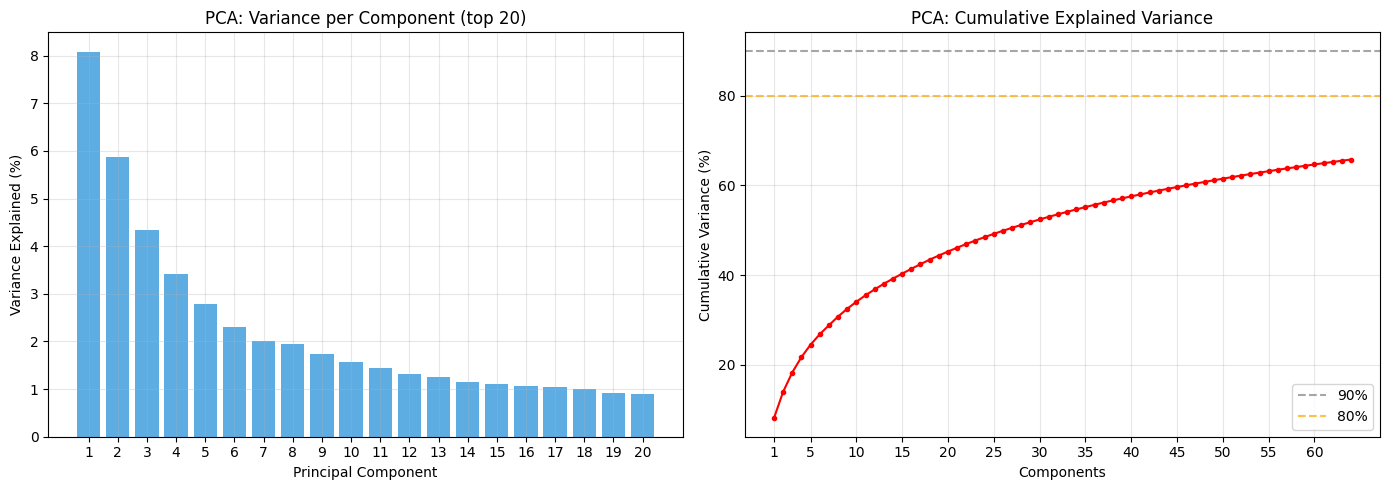

In [13]:
# StandardScaler
scaler       = StandardScaler(inputCol="raw_features", outputCol="scaled_features",
                              withStd=True, withMean=True)
scaler_model = scaler.fit(df_embeddings)
df_scaled    = scaler_model.transform(df_embeddings)
print(" Features standardized")

# PCA 1280 → N_PCA_COMPONENTS
pca_spark = SparkPCA(k=N_PCA_COMPONENTS, inputCol="scaled_features", outputCol="pca_features")
pca_model = pca_spark.fit(df_scaled)
df_pca    = pca_model.transform(df_scaled)

explained_var  = pca_model.explainedVariance.toArray()
cumulative_var = np.cumsum(explained_var)

print(f" PCA: 1280 → {N_PCA_COMPONENTS} dims")
print(f"   Variance retained: {cumulative_var[N_PCA_COMPONENTS-1]*100:.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ─── Plot 1: Individual Variance (Top 20) ──────────────────────────────────
top_n_individual = min(20, N_PCA_COMPONENTS)
axes[0].bar(range(1, top_n_individual + 1), explained_var[:top_n_individual] * 100, color="#3498db", alpha=0.8)
axes[0].set(xlabel="Principal Component", ylabel="Variance Explained (%)",
            title=f"PCA: Variance per Component (top {top_n_individual})")

# Explicitly set ticks to 1, 2, 3... up to top_n_individual
axes[0].set_xticks(range(1, top_n_individual + 1))
axes[0].grid(alpha=0.3)

# ─── Plot 2: Cumulative Explained Variance ─────────────────────────────────
axes[1].plot(range(1, N_PCA_COMPONENTS+1), cumulative_var[:N_PCA_COMPONENTS] * 100, "r-o", markersize=3)
axes[1].axhline(90, color="gray", linestyle="--", alpha=0.7, label="90%")
axes[1].axhline(80, color="orange", linestyle="--", alpha=0.7, label="80%")
axes[1].set(xlabel="Components", ylabel="Cumulative Variance (%)",
            title="PCA: Cumulative Explained Variance")

# Explicitly set ticks sequentially for the cumulative plot
# Optimization: If N_PCA_COMPONENTS is large, show every 5th or 10th label to prevent text overlap.
if N_PCA_COMPONENTS <= 25:
    axes[1].set_xticks(range(1, N_PCA_COMPONENTS + 1))
else:
    # If you have many components, this keeps the numeric order starting at 1 but skips steps to stay clean
    axes[1].set_xticks([1] + list(range(5, N_PCA_COMPONENTS + 1, 5)))

axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pca_explained_variance.png", dpi=120, bbox_inches="tight")
plt.show()

## 3.4 Join Image Features with Tabular Data

In [14]:
from itertools import chain

CSV_ABBREV_TO_FOLDER = {
    "ATL": "Atlanta",
    "BOS": "Boston",
    "CHI": "Chicago",
    "DEN": "Denver",
    "LA":  "Los_Angeles",
    "MIA": "Miami",
    "MSP": "Minneapolis",
    "NY":  "New_York",
    "ORL": "Orlando",
    "PHX": "Phoenix",
    "PHL": "Philadelphia",
    "PGH": "Pittsburgh",
    "RIV": "Riverside",
    "STL": "St._Louis",
    "SF":  "San_Francisco",
    "SD":  "San_Diego",
    "TPA": "Tampa",
    "ATX": "Austin",
    "DC":  "DC",
    "DAL": "Dallas",
    "CLT": "Charlotte",
    "DET": "Detroit",
    "HOU": "Houston",
    "SAC": "Sacramento",
    "BWI": "Baltimore",
    "CIN": "Cincinnati",
    "LV":  "Las_Vegas",
    "PDX": "Portland",
    "SA":  "San_Antonio",
    "SEA": "Seattle",
}

mapping_expr = F.create_map([F.lit(x) for x in chain(*CSV_ABBREV_TO_FOLDER.items())])

# Translate CSV city abbreviations → folder names
df_clean_mapped = df_clean.withColumn(
    "city_folder",
    F.coalesce(mapping_expr[F.trim(F.col("city"))], F.col("city"))   # Fall back to raw if not in map
)

# Verify translation quality
print("Sample of abbreviation → folder mapping:")
df_clean_mapped.select("city", "city_folder").distinct().orderBy("city").show(30, truncate=False)

# Check what image folder names were actually found on disk vs what the CSV provides
image_cities  = set(r["city"] for r in df_images.select("city").distinct().collect())
mapped_cities = set(r["city_folder"] for r in
                    df_clean_mapped.select("city_folder").distinct().collect())
matched = image_cities & mapped_cities
unmatched_img = image_cities - mapped_cities
unmatched_csv = mapped_cities - image_cities

print(f"\nImage folders found on disk : {sorted(image_cities)}")
print(f"Matched cities              : {len(matched)} — {sorted(matched)}")
if unmatched_img:
    print(f"⚠ Image folders with no CSV match : {sorted(unmatched_img)}")
    print(f"  → Add these to CSV_ABBREV_TO_FOLDER if you want their tabular data included.")
if unmatched_csv:
    print(f"⚠ CSV cities with no image folder : {sorted(list(unmatched_csv)[:10])}")

Sample of abbreviation → folder mapping:
+----+-------------+
|city|city_folder  |
+----+-------------+
|ATL |Atlanta      |
|ATX |Austin       |
|BOS |Boston       |
|BWI |Baltimore    |
|CHI |Chicago      |
|CIN |Cincinnati   |
|CLT |Charlotte    |
|DAL |Dallas       |
|DC  |DC           |
|DEN |Denver       |
|DET |Detroit      |
|HOU |Houston      |
|LA  |Los_Angeles  |
|LV  |Las_Vegas    |
|MIA |Miami        |
|MSP |Minneapolis  |
|NY  |New_York     |
|ORL |Orlando      |
|PDX |Portland     |
|PGH |Pittsburgh   |
|PHL |Philadelphia |
|PHX |Phoenix      |
|RIV |Riverside    |
|SA  |San_Antonio  |
|SAC |Sacramento   |
|SD  |San_Diego    |
|SEA |Seattle      |
|SF  |San_Francisco|
|STL |St._Louis    |
|TPA |Tampa        |
+----+-------------+


Image folders found on disk : ['Atlanta', 'Austin', 'Baltimore', 'Boston', 'Charlotte', 'Chicago', 'Cincinnati', 'DC', 'Dallas', 'Denver', 'Detroit', 'Houston', 'Las_Vegas', 'Los_Angeles', 'Miami', 'Minneapolis', 'New_York', 'Orlando', 'Philad

In [15]:
# Compute per-city tabular statistics, keyed on the folder name

city_stats = (
    df_clean_mapped
    .groupBy("city_folder")
    .agg(
        F.avg("median_sale_price").alias("avg_sale_price"),
        F.avg("Per Capita Income").alias("avg_income"),
        F.avg("amenity_score").alias("avg_amenity"),
        F.avg("unemployment_rate").alias("avg_unemployment"),
        F.avg("affordability_ratio").alias("avg_affordability"),
        F.avg("price_to_rent_ratio").alias("avg_ptr"),
        F.avg("Median Age").alias("avg_median_age"),
        F.avg("Median Commute Time").alias("avg_commute")
    )
)

# df_pca.city == image folder name; city_stats.city_folder == image folder name
# Both sides of the join are now on the same key space.
df_final = (
    df_pca.select("city", "zipcode_id", "pca_features")
    .join(city_stats, df_pca["city"] == city_stats["city_folder"], how="left")
    .drop("city_folder")
)

# ─── FIX Bug 4 (continued): Confirm join quality before clustering ────────────
total_rows  = df_final.count()
null_rows   = df_final.filter(F.col("avg_sale_price").isNull()).count()
join_rate   = (total_rows - null_rows) / total_rows * 100

print(f"Join result: {total_rows:,} rows | {null_rows:,} with null tabular cols ({100-join_rate:.1f}%)")

if join_rate < 50:
    print(
        "⚠ WARNING: More than half of image rows have no matching tabular data.\n"
        "  Check CSV_ABBREV_TO_FOLDER — likely some city abbreviations are missing.\n"
        "  The clustering will still work but without tabular enrichment for those cities."
    )

df_final = df_final.repartition(8).cache()
df_final.select("city", "zipcode_id", "avg_sale_price", "avg_income").show(10, truncate=False)

Join result: 35,099 rows | 0 with null tabular cols (0.0%)
+-------------+----------+------------------+------------------+
|city         |zipcode_id|avg_sale_price    |avg_income        |
+-------------+----------+------------------+------------------+
|Baltimore    |21122     |371250.7240586375 |45630.7718693111  |
|San_Francisco|94514     |1105956.5223358222|57371.8740879009  |
|Chicago      |46307     |238416.21015320648|37455.153880731195|
|Minneapolis  |55042     |275840.43240085675|38474.44680989161 |
|Minneapolis  |54003     |275840.43240085675|38474.44680989161 |
|San_Antonio  |78220     |243105.88515709643|29454.053629469123|
|St._Louis    |63104     |167198.43683665976|31301.570923169347|
|Los_Angeles  |91343     |783572.7601623631 |39367.06169796557 |
|Atlanta      |30345     |241522.15579685007|31873.386942343717|
|Sacramento   |95624     |441945.3420126019 |34930.65035829009 |
+-------------+----------+------------------+------------------+
only showing top 10 rows



---
# Stage 3.5 — Multimodal Feature Fusion: Geography × Wealth Latent Space

Combines **image-derived PCA features** (spatial / geographic appearance) with
**tabular socioeconomic indicators** (wealth / economic conditions) into a single
unified 2D latent space via a two-branch architecture:

- **Branch A — Geography** : MobileNetV2 → PCA(64) → StandardScaler → SparkPCA(16) → 1st latent axis
- **Branch B — Wealth** : Tabular socioeconomic features → StandardScaler → SparkPCA(16) → 2nd latent axis
- **Fusion** : Concatenate both branches → joint StandardScaler → SparkPCA(2) = *Geography × Wealth plane*

Downstream K-Means clustering operates on this fused 2D representation so that
every cluster groups regions by **both spatial appearance AND socioeconomic profile**.


In [16]:
# Stage 3.5-A  Tabular Socioeconomic Branch  (Wealth Axis)

TAB_FEATURES = [
    "avg_sale_price", "avg_income", "avg_amenity",
    "avg_unemployment", "avg_affordability", "avg_ptr",
    "avg_median_age", "avg_commute",
]

# Impute nulls in tabular cols with column median
tab_medians = {
    c: df_final.approxQuantile(c, [0.5], 0.05)[0]
    for c in TAB_FEATURES if c in df_final.columns
}
df_fused_base = df_final
for col_name, med_val in tab_medians.items():
    if med_val is not None:
        df_fused_base = df_fused_base.withColumn(
            col_name,
            F.when(F.col(col_name).isNull(), float(med_val)).otherwise(F.col(col_name))
        )

# Drop rows still missing pca_features
df_fused_base = df_fused_base.dropna(subset=["pca_features"]).cache()
print(f"Tabular imputation complete | Rows for fusion: {df_fused_base.count():,}")

# Assemble tabular features into a Spark vector
present_tab_features = [c for c in TAB_FEATURES if c in df_fused_base.columns]

tab_assembler = VectorAssembler(
    inputCols=present_tab_features,
    outputCol="tab_raw_vec",
    handleInvalid="skip"
)
df_tab_vec = tab_assembler.transform(df_fused_base)

# Scale tabular branch
tab_scaler = StandardScaler(inputCol="tab_raw_vec", outputCol="tab_scaled",
                            withStd=True, withMean=True)
tab_scaler_model = tab_scaler.fit(df_tab_vec)
df_tab_scaled = tab_scaler_model.transform(df_tab_vec)

# PCA on tabular branch: compress to N_TAB_PCA latent dims
N_TAB_PCA = min(8, len(present_tab_features))
tab_pca_spark = SparkPCA(k=N_TAB_PCA, inputCol="tab_scaled", outputCol="tab_pca")
tab_pca_model = tab_pca_spark.fit(df_tab_scaled)
df_tab_pca = tab_pca_model.transform(df_tab_scaled)

tab_var_retained = float(np.cumsum(tab_pca_model.explainedVariance.toArray())[N_TAB_PCA - 1]) * 100
print(f"   Tabular PCA: {len(present_tab_features)} features -> {N_TAB_PCA} dims "
      f"({tab_var_retained:.1f}% variance retained)")

df_tab_pca.select("city", "zipcode_id", "tab_pca").show(3, truncate=True)


Tabular imputation complete | Rows for fusion: 35,099
   Tabular PCA: 8 features -> 8 dims (100.0% variance retained)
+-------------+----------+--------------------+
|         city|zipcode_id|             tab_pca|
+-------------+----------+--------------------+
|    Baltimore|     21122|[0.06574896334880...|
|San_Francisco|     94514|[-6.2702236461302...|
|      Chicago|     46307|[1.00469841532996...|
+-------------+----------+--------------------+
only showing top 3 rows



In [17]:
# Stage 3.5-B  Fuse Image + Tabular -> Geography x Wealth 2D Latent Space
from pyspark.ml.linalg import Vectors, VectorUDT
import numpy as np

# Compress image branch further: N_PCA_COMPONENTS -> N_IMG_LATENT dims (Geography axis)
N_IMG_LATENT = min(16, N_PCA_COMPONENTS)

img_pca2 = SparkPCA(k=N_IMG_LATENT, inputCol="pca_features", outputCol="img_latent")
img_pca2_model = img_pca2.fit(df_tab_pca)
df_img_latent = img_pca2_model.transform(df_tab_pca)

img_var_ret = float(np.cumsum(img_pca2_model.explainedVariance.toArray())[N_IMG_LATENT - 1]) * 100
print(f"   Image branch PCA: {N_PCA_COMPONENTS} -> {N_IMG_LATENT} dims "
      f"({img_var_ret:.1f}% variance retained)")

# Concatenate both latent vectors into one fusion vector
@F.udf(VectorUDT())
def concat_vectors(v1, v2):
    if v1 is None or v2 is None:
        return None
    import numpy as _np
    arr = _np.concatenate([_np.array(v1), _np.array(v2)], axis=0)
    return Vectors.dense(arr.tolist())

df_fused_vec = (
    df_img_latent
    .withColumn("fused_raw", concat_vectors(F.col("img_latent"), F.col("tab_pca")))
    .dropna(subset=["fused_raw"])
)

total_fused_dims = N_IMG_LATENT + N_TAB_PCA
print(f"\nFusion complete: {N_IMG_LATENT}(geo) + {N_TAB_PCA}(wealth) = {total_fused_dims}-dim fused vector")
print(f"   Rows in fused DataFrame: {df_fused_vec.count():,}")

# Scale fused vector
fused_scaler = StandardScaler(inputCol="fused_raw", outputCol="fused_scaled",
                              withStd=True, withMean=True)
fused_scaler_model = fused_scaler.fit(df_fused_vec)
df_fused_scaled = fused_scaler_model.transform(df_fused_vec)

# Final PCA: fused -> 2D (the Geography x Wealth plane)
fused_pca = SparkPCA(k=2, inputCol="fused_scaled", outputCol="latent_2d")
fused_pca_model = fused_pca.fit(df_fused_scaled)
df_latent_2d = fused_pca_model.transform(df_fused_scaled)

latent_var = np.cumsum(fused_pca_model.explainedVariance.toArray())
print(f"\n   2D Latent Space variance: PC1={latent_var[0]*100:.1f}%  "
      f"PC2={latent_var[1]*100:.1f}%  total={latent_var[1]*100:.1f}%")

# Extract the raw 2 floats for clustering and plotting
@F.udf(FloatType())
def vec_get_0(v): return float(v[0]) if v is not None else None

@F.udf(FloatType())
def vec_get_1(v): return float(v[1]) if v is not None else None

df_latent_2d = (
    df_latent_2d
    .withColumn("geo_axis",    vec_get_0(F.col("latent_2d")))
    .withColumn("wealth_axis", vec_get_1(F.col("latent_2d")))
    .cache()
)

print("\nSample of 2D latent coordinates:")
df_latent_2d.select("city", "geo_axis", "wealth_axis").show(8, truncate=False)


   Image branch PCA: 64 -> 16 dims (63.0% variance retained)

Fusion complete: 16(geo) + 8(wealth) = 24-dim fused vector
   Rows in fused DataFrame: 35,099

   2D Latent Space variance: PC1=6.6%  PC2=12.9%  total=12.9%

Sample of 2D latent coordinates:
+-------------+-----------+-----------+
|city         |geo_axis   |wealth_axis|
+-------------+-----------+-----------+
|Baltimore    |1.2319545  |0.47477514 |
|San_Francisco|0.10807917 |1.4395534  |
|Chicago      |-0.9976145 |-2.1875536 |
|Minneapolis  |-0.15405211|-1.697544  |
|Minneapolis  |0.35725316 |-1.0963252 |
|San_Antonio  |-0.9026543 |0.2355369  |
|St._Louis    |0.8398979  |0.4877479  |
|Los_Angeles  |-2.1443572 |2.3373373  |
+-------------+-----------+-----------+
only showing top 8 rows



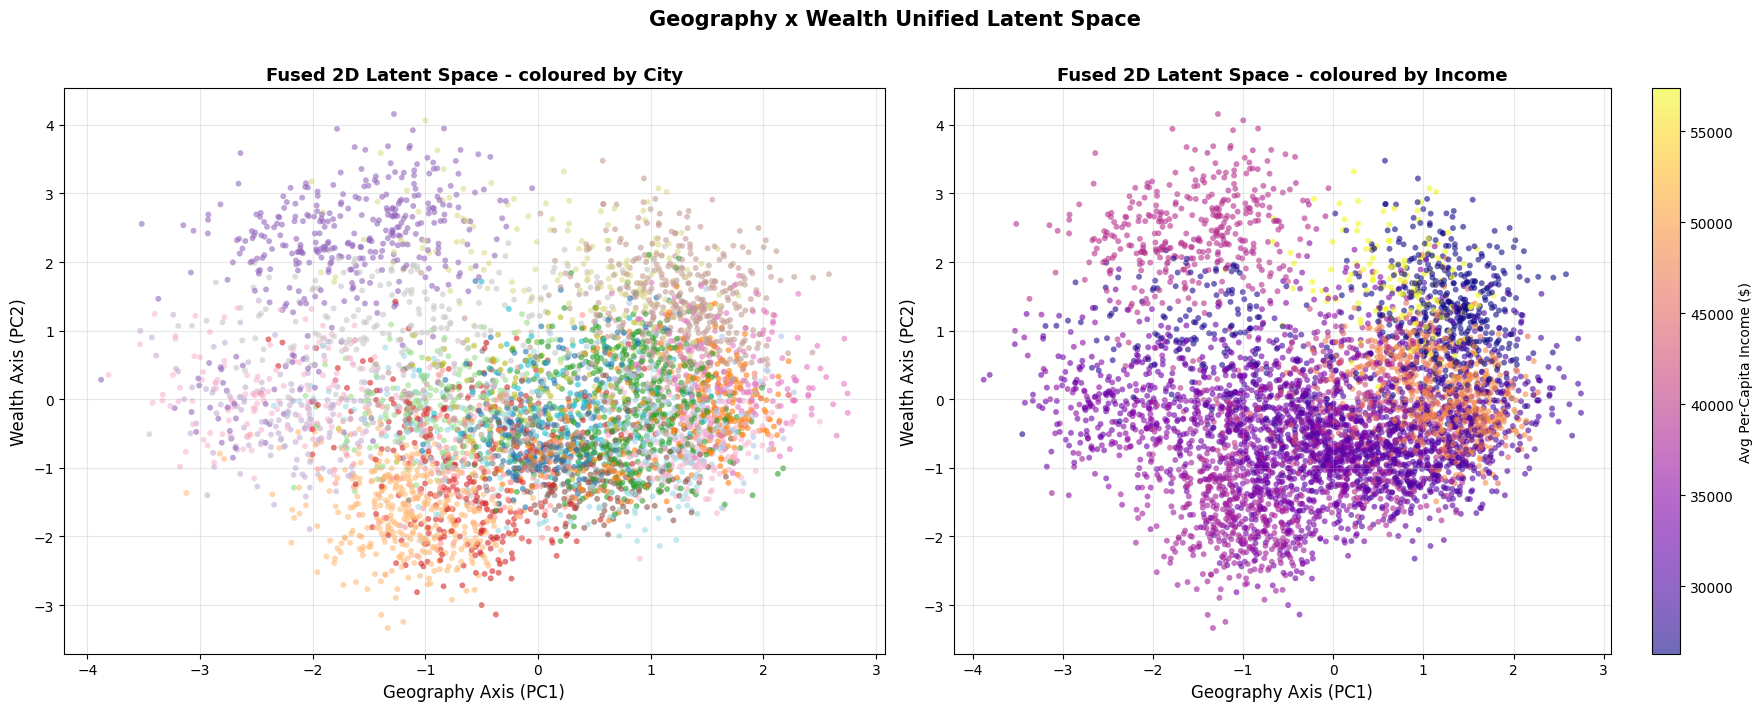

Latent space visualisation saved -> latent_space_2d.png


In [18]:
# Stage 3.5-C  Visualise the Geography x Wealth Latent Space (before clustering)

latent_vis = (
    df_latent_2d
    .select("city", "geo_axis", "wealth_axis", "avg_income", "avg_sale_price")
    .sample(fraction=min(1.0, 5000 / df_latent_2d.count()), seed=RANDOM_SEED)
    .toPandas()
    .dropna(subset=["geo_axis", "wealth_axis"])
)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

city_codes = latent_vis["city"].astype("category").cat.codes
sc1 = axes[0].scatter(latent_vis["geo_axis"], latent_vis["wealth_axis"],
                      c=city_codes, cmap="tab20", alpha=0.6, s=18, edgecolors="none")
axes[0].set_xlabel("Geography Axis (PC1)", fontsize=12)
axes[0].set_ylabel("Wealth Axis (PC2)", fontsize=12)
axes[0].set_title("Fused 2D Latent Space - coloured by City", fontsize=13, fontweight="bold")
axes[0].grid(alpha=0.3)

income_vals = latent_vis["avg_income"].fillna(latent_vis["avg_income"].median())
sc2 = axes[1].scatter(latent_vis["geo_axis"], latent_vis["wealth_axis"],
                      c=income_vals, cmap="plasma", alpha=0.6, s=18, edgecolors="none")
plt.colorbar(sc2, ax=axes[1], label="Avg Per-Capita Income ($)")
axes[1].set_xlabel("Geography Axis (PC1)", fontsize=12)
axes[1].set_ylabel("Wealth Axis (PC2)", fontsize=12)
axes[1].set_title("Fused 2D Latent Space - coloured by Income", fontsize=13, fontweight="bold")
axes[1].grid(alpha=0.3)

plt.suptitle("Geography x Wealth Unified Latent Space", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("latent_space_2d.png", dpi=150, bbox_inches="tight")
plt.show()
print("Latent space visualisation saved -> latent_space_2d.png")


---
# Stage 4 - K-Means Clustering on Geography x Wealth Latent Space
## 4.1 Top-K Evaluation: Silhouette · Balance · Interpretability · Centroids

In [19]:
# Stage 4.1-A Top-K Evaluation on Geography x Wealth Fused Latent Space
from sklearn.metrics import silhouette_score as sk_silhouette
import warnings; warnings.filterwarnings("ignore")

# Prepare clustering DataFrame (latent_2d is the clustering feature)
# Carry ALL socioeconomic columns so Stage 4.4 cluster_profile can aggregate them
_all_tab_cols = [
    "avg_sale_price", "avg_income", "avg_amenity",
    "avg_unemployment", "avg_affordability",
    "avg_ptr", "avg_median_age", "avg_commute",
]
_present_tab_cols = [c for c in _all_tab_cols if c in df_latent_2d.columns]

df_for_cluster = (
    df_latent_2d
    .dropna(subset=["latent_2d"])
    .select(
        "city", "zipcode_id", "latent_2d",
        "geo_axis", "wealth_axis",
        *_present_tab_cols
    )
    .cache()
)
n_cluster_rows = df_for_cluster.count()
print(f"Rows for clustering (latent_2d): {n_cluster_rows:,}")

if n_cluster_rows < 10:
    raise RuntimeError(
        f"Only {n_cluster_rows} rows - cannot cluster. "
        "Check that Stage 3.5 fusion succeeded."
    )

MAX_K   = min(12, n_cluster_rows // 2)
k_range = range(2, MAX_K + 1)

evaluator_latent = ClusteringEvaluator(
    featuresCol="latent_2d",
    predictionCol="cluster",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

records = []

print(f"{'K':>3}  {'WCSSE':>12}  {'Sil(Spark)':>10}  {'Sil(sklearn)':>12}  "
      f"{'CV_Balance':>11}  {'Interp':>8}")
print("-" * 65)

for k in k_range:
    km = KMeans(
        featuresCol="latent_2d", predictionCol="cluster",
        k=k, maxIter=60, seed=RANDOM_SEED, initMode="k-means||", initSteps=5
    )
    km_model  = km.fit(df_for_cluster)
    df_pred_k = km_model.transform(df_for_cluster)

    wcsse  = km_model.summary.trainingCost
    sil_sp = evaluator_latent.evaluate(df_pred_k)

    # Cluster size balance: CV = std / mean of cluster sizes (lower = better)
    sizes = [r["count"] for r in
             df_pred_k.groupBy("cluster").count().collect()]
    sizes_arr = np.array(sizes, dtype=float)
    cv_balance = float(np.std(sizes_arr) / np.mean(sizes_arr))

    # Interpretability: mean pairwise inter-centroid distance in tabular space
    profile_cols = ["avg_sale_price", "avg_income", "avg_amenity",
                    "avg_unemployment", "avg_affordability"]
    present_profile = [c for c in profile_cols if c in df_pred_k.columns]

    centroid_profiles = (
        df_pred_k
        .groupBy("cluster")
        .agg(*[F.avg(c).alias(c) for c in present_profile])
        .orderBy("cluster")
        .toPandas()
    )
    prof_vals = centroid_profiles[present_profile].values
    col_stds  = prof_vals.std(axis=0) + 1e-9
    prof_norm = prof_vals / col_stds
    dists = []
    for i in range(len(prof_norm)):
        for j in range(i + 1, len(prof_norm)):
            dists.append(np.linalg.norm(prof_norm[i] - prof_norm[j]))
    interp_score = float(np.mean(dists)) if dists else 0.0

    # sklearn silhouette on sampled 2D latent coords
    sample_size = min(2000, n_cluster_rows)
    sample_frac = sample_size / n_cluster_rows
    lat_sample  = (
        df_pred_k
        .select("geo_axis", "wealth_axis", "cluster")
        .sample(fraction=sample_frac, seed=RANDOM_SEED)
        .toPandas()
        .dropna()
    )
    if len(lat_sample) >= 2 * k:
        sil_sk = float(sk_silhouette(
            lat_sample[["geo_axis", "wealth_axis"]].values,
            lat_sample["cluster"].values
        ))
    else:
        sil_sk = float("nan")

    records.append({
        "K":                  k,
        "WCSSE":              wcsse,
        "Silhouette_Spark":   sil_sp,
        "Silhouette_sklearn": sil_sk,
        "CV_Balance":         cv_balance,
        "Interp_Score":       interp_score,
        "cluster_sizes":      sizes,
        "centroid_profiles":  centroid_profiles,
        "model":              km_model,
    })

    print(f"{k:>3}  {wcsse:>12.3e}  {sil_sp:>10.4f}  {sil_sk:>12.4f}  "
          f"{cv_balance:>11.4f}  {interp_score:>8.4f}")

# Attach silhouette list and inertias for Stage 5 compatibility
silhouettes = [r["Silhouette_Spark"] for r in records]
inertias    = [r["WCSSE"] for r in records]

print("\nTop-K evaluation loop complete")


Rows for clustering (latent_2d): 35,099
  K         WCSSE  Sil(Spark)  Sil(sklearn)   CV_Balance    Interp
-----------------------------------------------------------------
  2     7.362e+04      0.5009        0.3487       0.3724    4.4721
  3     4.222e+04      0.5728        0.3993       0.3652    3.8585
  4     3.129e+04      0.5388        0.3676       0.3542    3.5902
  5     2.448e+04      0.5370        0.3668       0.3877    3.3617
  6     1.996e+04      0.5473        0.3866       0.3355    3.2750
  7     1.675e+04      0.5460        0.3829       0.2801    3.1920
  8     1.555e+04      0.5274        0.3681       0.4209    3.1468
  9     1.364e+04      0.5193        0.3549       0.1984    3.1060
 10     1.236e+04      0.5187        0.3463       0.3248    3.0725
 11     1.148e+04      0.4970        0.3418       0.2686    3.0436
 12     1.047e+04      0.4990        0.3336       0.3232    3.0403

Top-K evaluation loop complete


  TOP-K RANKING  (Geography x Wealth Clustering)
 K  Silhouette_Spark  Silhouette_sklearn  CV_Balance  Interp_Score  Composite_Score
 3            0.5728              0.3993      0.3652        3.8585           0.6466
 7            0.5460              0.3829      0.2801        3.1920           0.4804
 9            0.5193              0.3549      0.1984        3.1060           0.4316
 6            0.5473              0.3866      0.3355        3.2750           0.4299
 4            0.5388              0.3676      0.3542        3.5902           0.4256
 2            0.5009              0.3487      0.3724        4.4721           0.3861
 5            0.5370              0.3668      0.3877        3.3617           0.3234
10            0.5187              0.3463      0.3248        3.0725           0.2506
11            0.4970              0.3418      0.2686        3.0436           0.2061
 8            0.5274              0.3681      0.4209        3.1468           0.1825
12            0.4990       

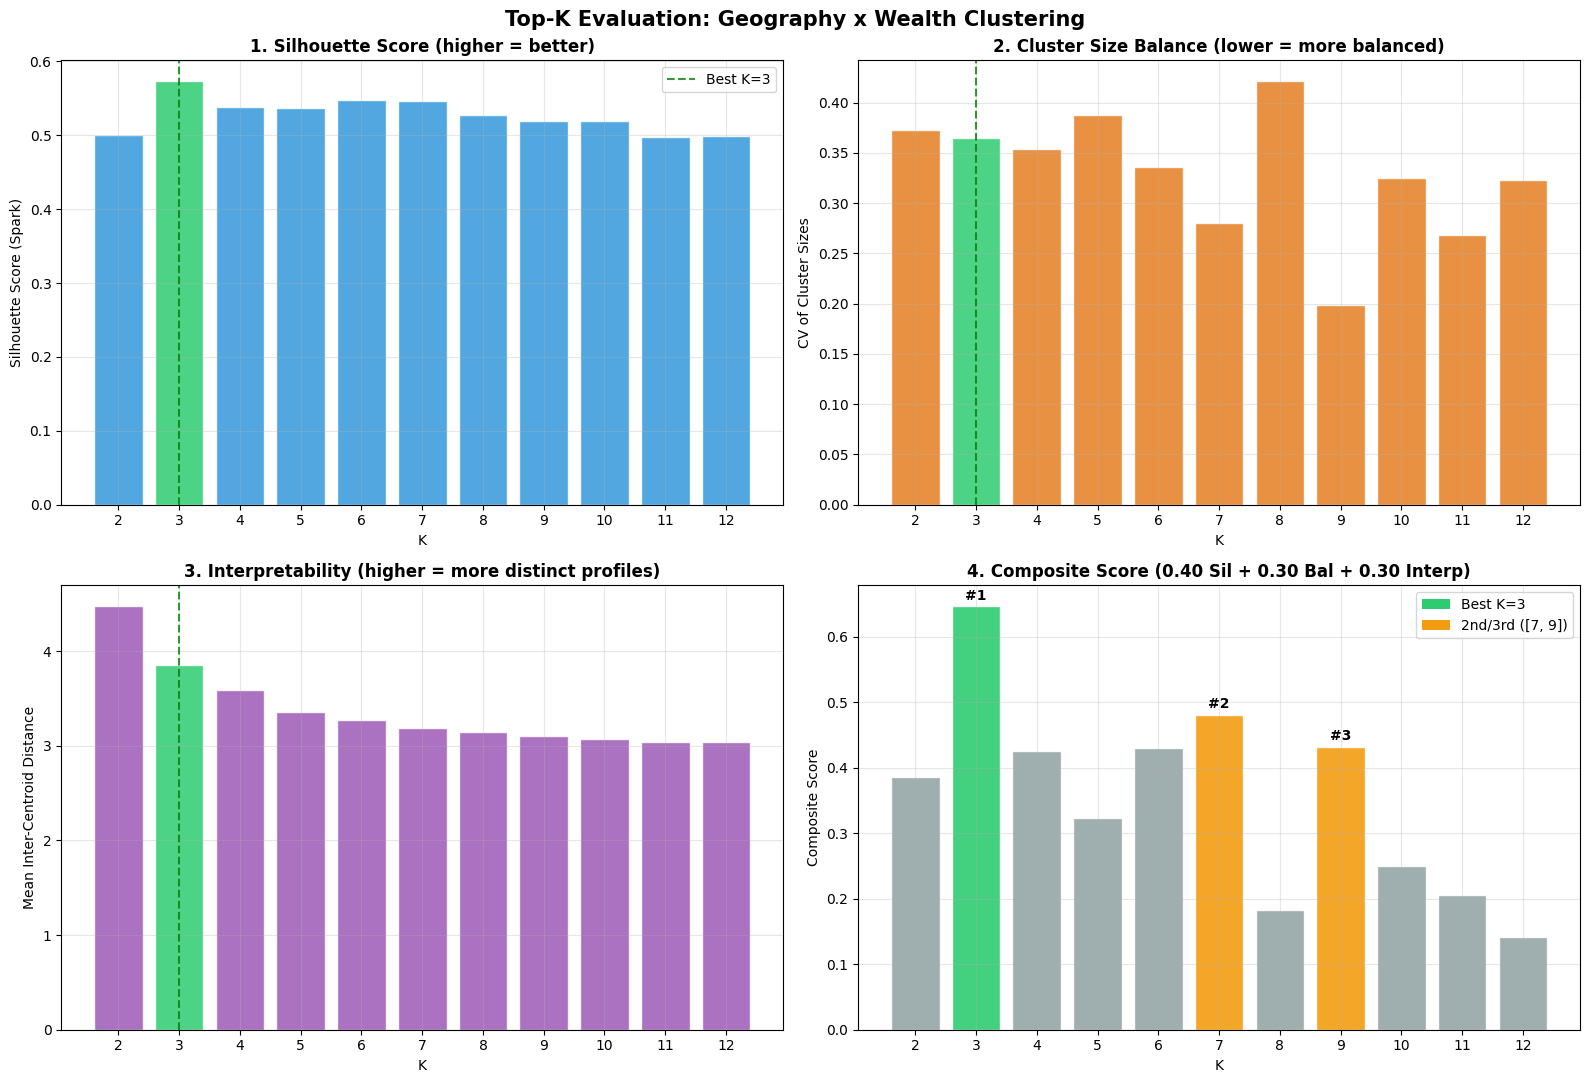

Top-K evaluation plot saved -> topk_evaluation.png


In [20]:
# Stage 4.1-B & C: Composite Ranking and 4-Panel Comparison Plot

# --- 1. Compute the Composite Scores ---
eval_df = pd.DataFrame([{
    "K":                  r["K"],
    "WCSSE":              r["WCSSE"],
    "Silhouette_Spark":   r["Silhouette_Spark"],
    "Silhouette_sklearn": r["Silhouette_sklearn"],
    "CV_Balance":         r["CV_Balance"],
    "Interp_Score":       r["Interp_Score"],
} for r in records])

def norm_col(series, higher_better=True):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([0.5] * len(series), index=series.index)
    n = (series - mn) / (mx - mn)
    return n if higher_better else (1 - n)

eval_df["sil_norm"]     = norm_col(eval_df["Silhouette_Spark"],   higher_better=True)
eval_df["balance_norm"] = norm_col(eval_df["CV_Balance"],          higher_better=False)
eval_df["interp_norm"]  = norm_col(eval_df["Interp_Score"],        higher_better=True)

W_SIL, W_BAL, W_INTERP = 0.40, 0.30, 0.30
eval_df["Composite_Score"] = (
    W_SIL   * eval_df["sil_norm"]
    + W_BAL   * eval_df["balance_norm"]
    + W_INTERP * eval_df["interp_norm"]
)

eval_df_sorted = eval_df.sort_values("Composite_Score", ascending=False).reset_index(drop=True)

# Define variables needed for downstream cells and the visual plot
TOP_K_VALUES = eval_df_sorted["K"].head(3).tolist()
best_k       = TOP_K_VALUES[0]

# Push Composite_Score back into the global records memory so CELL 3 doesn't crash
score_map = dict(zip(eval_df["K"], eval_df["Composite_Score"]))
for r in records:
    r["Composite_Score"] = score_map[r["K"]]

# Print out the console table summary
print("=" * 80)
print("  TOP-K RANKING  (Geography x Wealth Clustering)")
print("=" * 80)
print(eval_df_sorted[[
    "K", "Silhouette_Spark", "Silhouette_sklearn",
    "CV_Balance", "Interp_Score", "Composite_Score"
]].to_string(index=False, float_format="{:.4f}".format))
print("=" * 80)
print(f"\n  Top-3 K values : {TOP_K_VALUES}")
print(f"  Best K          : {best_k}\n")


# --- 2. Generate the 4-Panel Comparison Visualization ---
k_list = list(k_range)

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("Top-K Evaluation: Geography x Wealth Clustering", fontsize=15, fontweight="bold")

# Panel 1: Silhouette Score
colors_main = ["#2ecc71" if k == best_k else "#3498db" for k in k_list]
axes[0, 0].bar(k_list, eval_df["Silhouette_Spark"], color=colors_main, alpha=0.85, edgecolor="white")
axes[0, 0].set_xlabel("K"); axes[0, 0].set_ylabel("Silhouette Score (Spark)")
axes[0, 0].set_title("1. Silhouette Score (higher = better)", fontweight="bold")
axes[0, 0].axvline(best_k, color="green", linestyle="--", alpha=0.8, label=f"Best K={best_k}")
axes[0, 0].legend(); axes[0, 0].grid(alpha=0.3); axes[0, 0].set_xticks(k_list)

# Panel 2: Cluster Size Balance (CV)
colors_bal = ["#2ecc71" if k == best_k else "#e67e22" for k in k_list]
axes[0, 1].bar(k_list, eval_df["CV_Balance"], color=colors_bal, alpha=0.85, edgecolor="white")
axes[0, 1].set_xlabel("K"); axes[0, 1].set_ylabel("CV of Cluster Sizes")
axes[0, 1].set_title("2. Cluster Size Balance (lower = more balanced)", fontweight="bold")
axes[0, 1].axvline(best_k, color="green", linestyle="--", alpha=0.8)
axes[0, 1].grid(alpha=0.3); axes[0, 1].set_xticks(k_list)

# Panel 3: Interpretability Score
colors_int = ["#2ecc71" if k == best_k else "#9b59b6" for k in k_list]
axes[1, 0].bar(k_list, eval_df["Interp_Score"], color=colors_int, alpha=0.85, edgecolor="white")
axes[1, 0].set_xlabel("K"); axes[1, 0].set_ylabel("Mean Inter-Centroid Distance")
axes[1, 0].set_title("3. Interpretability (higher = more distinct profiles)", fontweight="bold")
axes[1, 0].axvline(best_k, color="green", linestyle="--", alpha=0.8)
axes[1, 0].grid(alpha=0.3); axes[1, 0].set_xticks(k_list)

# Panel 4: Composite Score
comp_colors = []
for k in k_list:
    if k == TOP_K_VALUES[0]:    comp_colors.append("#2ecc71")
    elif k in TOP_K_VALUES[1:]: comp_colors.append("#f39c12")
    else:                       comp_colors.append("#95a5a6")

axes[1, 1].bar(k_list, eval_df["Composite_Score"], color=comp_colors, alpha=0.9, edgecolor="white")
axes[1, 1].set_xlabel("K"); axes[1, 1].set_ylabel("Composite Score")
axes[1, 1].set_title("4. Composite Score (0.40 Sil + 0.30 Bal + 0.30 Interp)", fontweight="bold")
axes[1, 1].grid(alpha=0.3); axes[1, 1].set_xticks(k_list)

for rank, k_val in enumerate(TOP_K_VALUES, 1):
    idx = k_list.index(k_val)
    score = eval_df.loc[eval_df["K"] == k_val, "Composite_Score"].values[0]
    axes[1, 1].annotate(f"#{rank}", (k_val, score),
                        textcoords="offset points", xytext=(0, 5),
                        ha="center", fontsize=10, fontweight="bold")

legend_els = [Patch(facecolor="#2ecc71", label=f"Best K={TOP_K_VALUES[0]}")]
if len(TOP_K_VALUES) > 1:
    legend_els.append(Patch(facecolor="#f39c12", label=f"2nd/3rd ({TOP_K_VALUES[1:]})"))
axes[1, 1].legend(handles=legend_els)

plt.tight_layout()
plt.savefig("topk_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Top-K evaluation plot saved -> topk_evaluation.png")

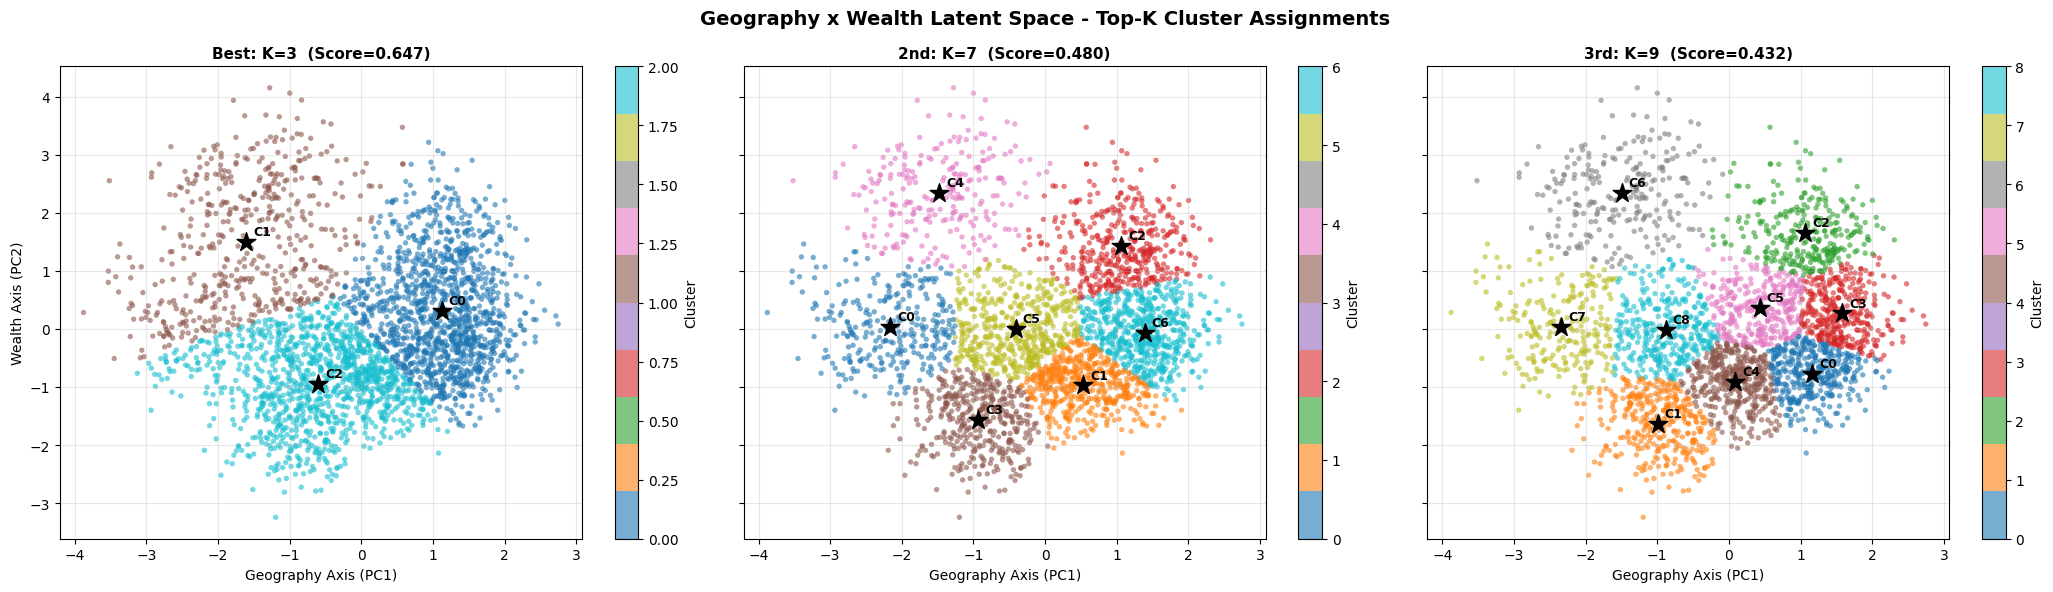

Latent scatter for top-K saved -> topk_latent_scatter.png


In [21]:
# Stage 4.1-C  Latent Space Scatter for Top-3 K Values

n_top  = min(3, len(TOP_K_VALUES))
fig, axes = plt.subplots(1, n_top, figsize=(7 * n_top, 6), sharey=True)
if n_top == 1:
    axes = [axes]
fig.suptitle("Geography x Wealth Latent Space - Top-K Cluster Assignments",
             fontsize=14, fontweight="bold")

sample_size_vis = min(3000, n_cluster_rows)

for ax_idx, k_val in enumerate(TOP_K_VALUES[:n_top]):
    rec    = next(r for r in records if r["K"] == k_val)
    km_mdl = rec["model"]

    df_vis_k = (
        km_mdl.transform(df_for_cluster)
        .select("geo_axis", "wealth_axis", "cluster", "city")
        .sample(fraction=min(1.0, sample_size_vis / n_cluster_rows), seed=RANDOM_SEED)
        .toPandas()
        .dropna(subset=["geo_axis", "wealth_axis"])
    )

    sc = axes[ax_idx].scatter(
        df_vis_k["geo_axis"], df_vis_k["wealth_axis"],
        c=df_vis_k["cluster"], cmap="tab10",
        alpha=0.6, s=15, edgecolors="none"
    )
    plt.colorbar(sc, ax=axes[ax_idx], label="Cluster")

    centroid_coords = df_vis_k.groupby("cluster")[["geo_axis", "wealth_axis"]].mean()
    for ci, row in centroid_coords.iterrows():
        axes[ax_idx].scatter(row["geo_axis"], row["wealth_axis"],
                             s=200, c="black", marker="*", zorder=6)
        axes[ax_idx].annotate(f"C{ci}", (row["geo_axis"], row["wealth_axis"]),
                              textcoords="offset points", xytext=(5, 5),
                              fontsize=9, fontweight="bold")

    rank_str = ["Best", "2nd", "3rd"][ax_idx]
    axes[ax_idx].set_title(
        f"{rank_str}: K={k_val}  (Score={rec['Composite_Score']:.3f})",
        fontsize=11, fontweight="bold"
    )
    axes[ax_idx].set_xlabel("Geography Axis (PC1)")
    if ax_idx == 0:
        axes[ax_idx].set_ylabel("Wealth Axis (PC2)")
    axes[ax_idx].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("topk_latent_scatter.png", dpi=150, bbox_inches="tight")
plt.show()
print("Latent scatter for top-K saved -> topk_latent_scatter.png")


## 4.2 Final K-Means Model

In [22]:
# Stage 4.2  Final K-Means Model  (on Geography x Wealth Latent Space)
OPTIMAL_K = 2  # Override here if desired, e.g. OPTIMAL_K = 6

final_kmeans = KMeans(
    featuresCol="latent_2d", predictionCol="cluster",
    k=OPTIMAL_K, maxIter=100, seed=RANDOM_SEED,
    initMode="k-means||", initSteps=10
)

final_model  = final_kmeans.fit(df_for_cluster)
df_clustered = final_model.transform(df_for_cluster).cache()
df_clustered.count()

final_sil   = evaluator_latent.evaluate(df_clustered)
final_wcsse = final_model.summary.trainingCost

print(f"Final K-Means (Geography x Wealth Latent Space)")
print(f"   K           : {OPTIMAL_K}")
print(f"   WCSSE       : {final_wcsse:.4e}")
print(f"   Silhouette  : {final_sil:.4f}")
print("\nCluster sizes:")
df_clustered.groupBy("cluster").count().orderBy("cluster").show()


Final K-Means (Geography x Wealth Latent Space)
   K           : 2
   WCSSE       : 6.8478e+04
   Silhouette  : 0.5088

Cluster sizes:
+-------+-----+
|cluster|count|
+-------+-----+
|      0|15838|
|      1|19261|
+-------+-----+



## 4.3 Cluster Visualization: PCA 2D & t-SNE

Running t-SNE on 2D latent vectors...
t-SNE complete


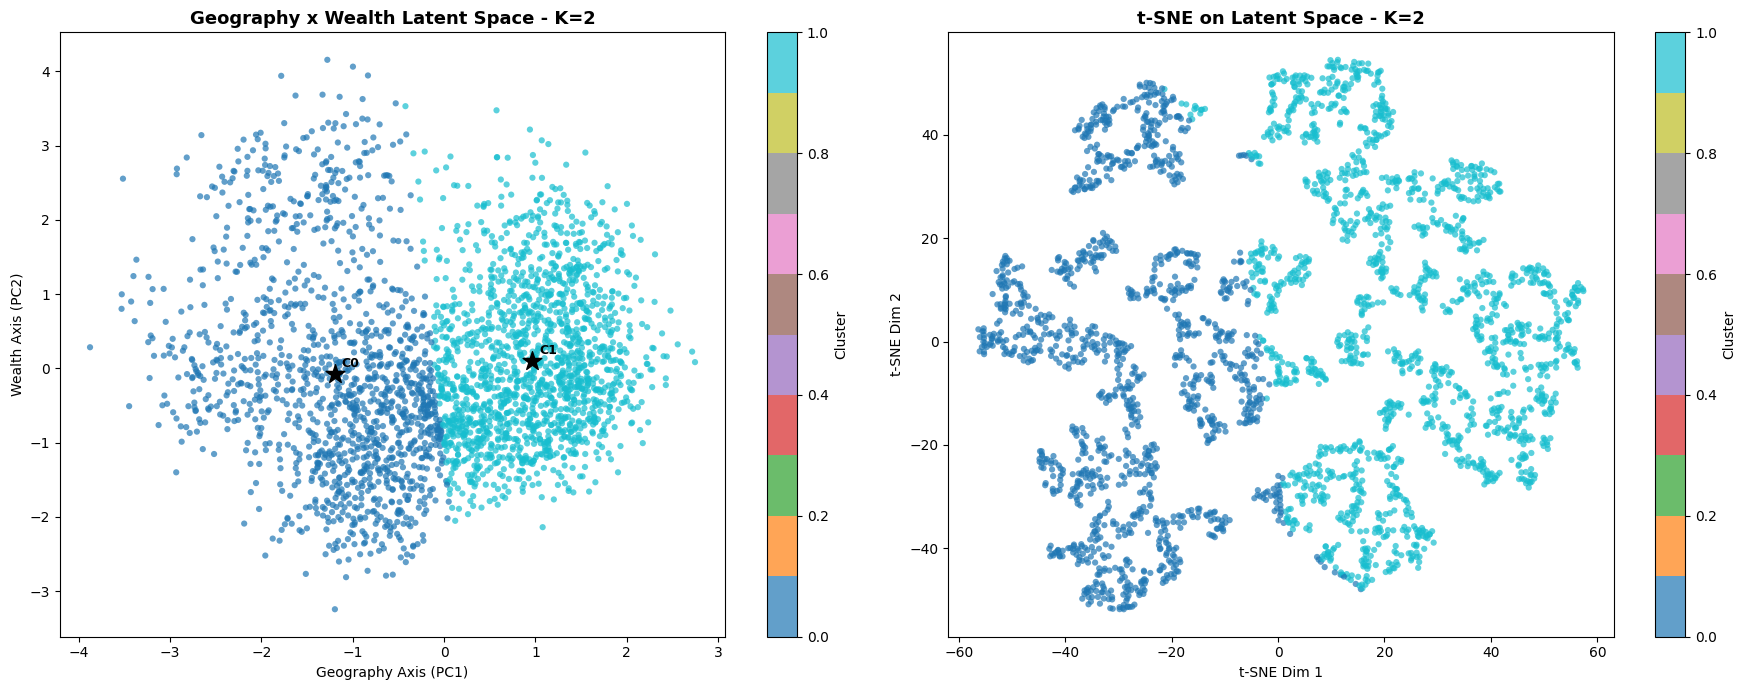

In [23]:
# Stage 4.3  Cluster Visualization: Latent 2D and t-SNE

viz_sample = (
    df_clustered
    .select("city", "cluster", "latent_2d", "geo_axis", "wealth_axis",
            "avg_sale_price", "avg_income", "avg_amenity")
    .sample(fraction=min(1.0, 3000 / df_clustered.count()), seed=RANDOM_SEED)
    .toPandas()
)

# Use latent_2d (2D already) directly for the primary plot
latent_data = viz_sample[["geo_axis", "wealth_axis"]].fillna(0).values
labels      = viz_sample["cluster"].values

# Also run t-SNE on the latent_2d vectors for visual quality comparison
latent_arr = np.array([v.toArray() for v in viz_sample["latent_2d"]])
print("Running t-SNE on 2D latent vectors...")
tsne = TSNE(
    n_components=2,
    perplexity=min(30, max(5, len(viz_sample) // 4)),
    max_iter=1000,
    random_state=RANDOM_SEED,
    n_jobs=-1
)
proj_tsne = tsne.fit_transform(latent_arr)
print("t-SNE complete")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
for ax, proj, title in [
    (axes[0], latent_data, f"Geography x Wealth Latent Space - K={OPTIMAL_K}"),
    (axes[1], proj_tsne,   f"t-SNE on Latent Space - K={OPTIMAL_K}")
]:
    sc = ax.scatter(proj[:, 0], proj[:, 1], c=labels, cmap="tab10",
                    alpha=0.7, s=20, edgecolors="none")
    plt.colorbar(sc, ax=ax, label="Cluster")
    ax.set_title(title, fontsize=13, fontweight="bold")

# Centroids on latent plot
geo_means    = viz_sample.groupby("cluster")["geo_axis"].mean()
wealth_means = viz_sample.groupby("cluster")["wealth_axis"].mean()
for ci in range(OPTIMAL_K):
    if ci in geo_means.index:
        cx, cy = geo_means[ci], wealth_means[ci]
        axes[0].scatter(cx, cy, s=200, c="black", marker="*", zorder=5)
        axes[0].annotate(f"C{ci}", (cx, cy), fontsize=9, fontweight="bold",
                         textcoords="offset points", xytext=(5, 5))

axes[0].set_xlabel("Geography Axis (PC1)")
axes[0].set_ylabel("Wealth Axis (PC2)")
axes[1].set_xlabel("t-SNE Dim 1")
axes[1].set_ylabel("t-SNE Dim 2")

plt.tight_layout()
plt.savefig("cluster_visualization.png", dpi=150, bbox_inches="tight")
plt.show()


## 4.4 Cluster Profiling

In [24]:
# Build agg expressions only for columns that actually exist in df_clustered
_profile_col_map = {
    "avg_sale_price":   "avg_sale_price",
    "avg_income":       "avg_income",
    "avg_amenity":      "avg_amenity_score",
    "avg_unemployment": "avg_unemployment",
    "avg_affordability":"avg_affordability",
    "avg_ptr":          "avg_price_to_rent",
    "avg_median_age":   "avg_median_age",
    "avg_commute":      "avg_commute_min",
}
_existing_cols = df_clustered.columns
_agg_exprs = [F.count("*").alias("count")] + [
    F.avg(src_col).alias(alias_col)
    for src_col, alias_col in _profile_col_map.items()
    if src_col in _existing_cols
]

cluster_profile = (
    df_clustered
    .groupBy("cluster")
    .agg(*_agg_exprs)
    .orderBy("cluster")
    .toPandas()
)

display_profile = cluster_profile.copy()
display_profile["avg_sale_price"] = display_profile["avg_sale_price"].map(
    lambda x: f"${x/1e6:.2f}M" if pd.notna(x) else "N/A")
display_profile["avg_income"] = display_profile["avg_income"].map(
    lambda x: f"${x:,.0f}" if pd.notna(x) else "N/A")
print("=== Cluster Profiles ===")
print(display_profile.to_string(index=False))

=== Cluster Profiles ===
 cluster  count avg_sale_price avg_income  avg_amenity_score  avg_unemployment  avg_affordability  avg_price_to_rent  avg_median_age  avg_commute_min
       0  15838         $0.36M    $34,914         167.089944          7.764113          10.202315          22.828856       38.971980     12096.039758
       1  19261         $0.39M    $36,523         200.001416          6.517126           9.648786          25.535519       36.711674      8122.102694


In [25]:
# Radar chart
metrics  = ["avg_sale_price", "avg_income", "avg_amenity_score", "avg_unemployment", "avg_affordability"]
radar_df = cluster_profile[["cluster"] + metrics].copy()
for m in metrics:
    col_min, col_max = radar_df[m].min(), radar_df[m].max()
    if col_max > col_min:
        radar_df[m] = (radar_df[m] - col_min) / (col_max - col_min)

fig = go.Figure()
for _, row in radar_df.iterrows():
    fig.add_trace(go.Scatterpolar(
        r=[row[m] for m in metrics] + [row[metrics[0]]],
        theta=metrics + [metrics[0]],
        fill="toself", name=f"Cluster {int(row['cluster'])}", opacity=0.7
    ))
fig.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    title=f"Cluster Profiles — Radar Chart (K={OPTIMAL_K})",
    width=700, height=600
)
fig.write_html("cluster_radar.html")
fig.show()
print(" Radar chart saved")

 Radar chart saved


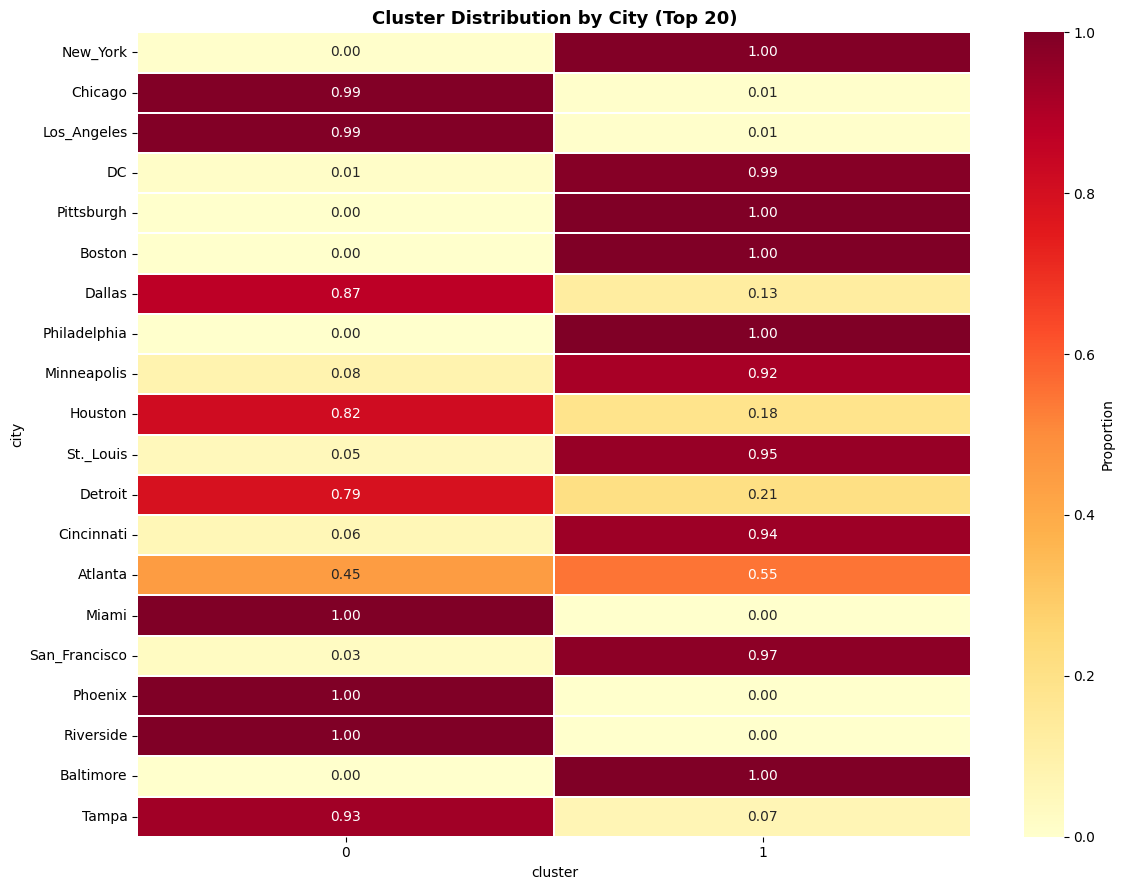

In [26]:
# City × Cluster heatmap
city_cluster = (
    df_clustered
    .groupBy("city", "cluster")
    .count()
    .toPandas()
    .pivot(index="city", columns="cluster", values="count")
    .fillna(0)
)
city_cluster_norm = city_cluster.div(city_cluster.sum(axis=1), axis=0)
top20_cities = city_cluster.sum(axis=1).sort_values(ascending=False).head(20).index

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(city_cluster_norm.loc[top20_cities], annot=True, fmt=".2f",
            cmap="YlOrRd", linewidths=0.3, ax=ax,
            cbar_kws={"label": "Proportion"})
ax.set_title("Cluster Distribution by City (Top 20)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("city_cluster_heatmap.png", dpi=120, bbox_inches="tight")
plt.show()

## 4.5 Sample Images per Cluster

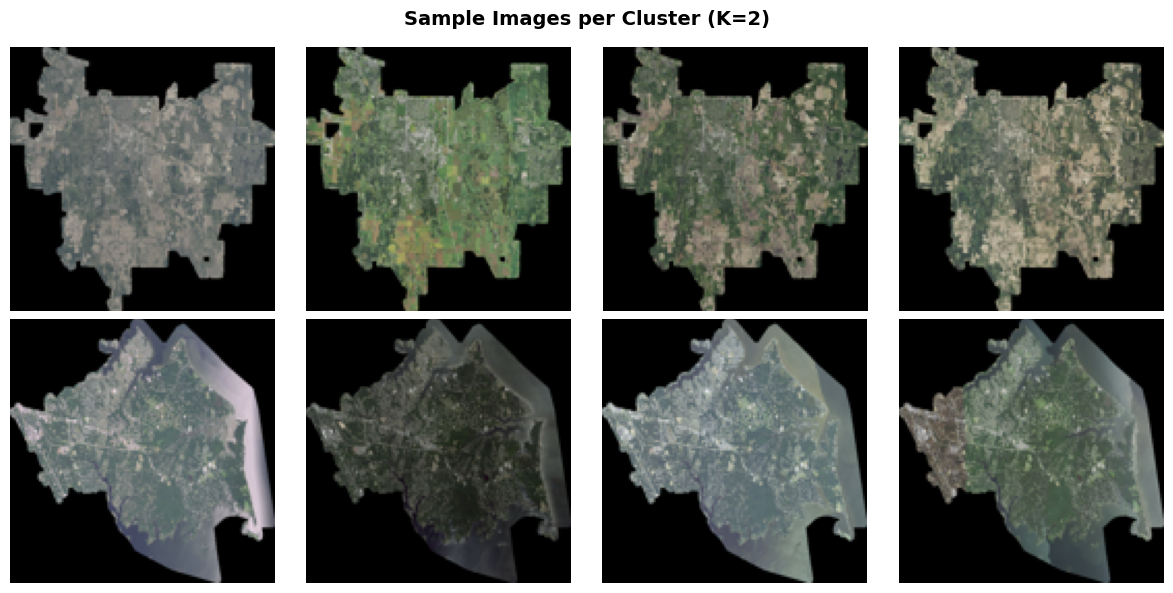

 Sample images saved


In [27]:
cluster_samples = (
    df_clustered
    .select("city", "zipcode_id", "cluster")
    .join(df_images.select("city", "zipcode_id", "image_path"),
          on=["city", "zipcode_id"], how="left")
    .dropna(subset=["image_path"])
)

SAMPLES_PER_CLUSTER = 4
fig, axes = plt.subplots(OPTIMAL_K, SAMPLES_PER_CLUSTER,
                         figsize=(SAMPLES_PER_CLUSTER * 3, OPTIMAL_K * 3))
fig.suptitle(f"Sample Images per Cluster (K={OPTIMAL_K})", fontsize=14, fontweight="bold")

for k in range(OPTIMAL_K):
    sample_paths = (
        cluster_samples.filter(F.col("cluster") == k)
        .select("image_path")
        .limit(SAMPLES_PER_CLUSTER * 3)
        .toPandas()["image_path"]
        .dropna()
        .head(SAMPLES_PER_CLUSTER)
    )
    for j in range(SAMPLES_PER_CLUSTER):
        ax = axes[k][j] if OPTIMAL_K > 1 else axes[j]
        if j < len(sample_paths):
            try:
                img = Image.open(sample_paths.iloc[j]).convert("RGB").resize((128, 128))
                ax.imshow(np.array(img))
            except Exception as e:
                ax.set_facecolor("#cccccc")
                ax.text(0.5, 0.5, str(e)[:20], ha="center", va="center",
                        transform=ax.transAxes, fontsize=7)
        else:
            ax.set_facecolor("#eeeeee")
        ax.axis("off")
        if j == 0:
            ax.set_ylabel(f"Cluster {k}", fontsize=11, fontweight="bold",
                          rotation=0, labelpad=55, va="center")

plt.tight_layout()
plt.savefig("cluster_sample_images.png", dpi=120, bbox_inches="tight")
plt.show()
print(" Sample images saved")

---
# Stage 5 — Results & Evaluation

In [28]:
eval_results = pd.DataFrame({
    "K":          list(k_range),
    "WCSSE":      inertias,
    "Silhouette": silhouettes,
})
eval_results["Delta_WCSSE"] = eval_results["WCSSE"].diff()
eval_results["WCSSE_Ratio"] = eval_results["WCSSE"] / eval_results["WCSSE"].shift(1)
print("=== K-Means Evaluation Metrics ===")
print(eval_results.to_string(index=False))
print(f"\n★ Optimal K = {OPTIMAL_K} (Silhouette = {max(silhouettes):.4f})")
print(f"  Final Silhouette = {final_sil:.4f} | WCSSE = {final_wcsse:.4e}")

=== K-Means Evaluation Metrics ===
 K        WCSSE  Silhouette   Delta_WCSSE  WCSSE_Ratio
 2 73617.597003    0.500937           NaN          NaN
 3 42221.891054    0.572775 -31395.705949     0.573530
 4 31285.003359    0.538781 -10936.887696     0.740966
 5 24482.615833    0.537038  -6802.387526     0.782567
 6 19959.803496    0.547307  -4522.812337     0.815264
 7 16747.031437    0.546033  -3212.772060     0.839038
 8 15548.787344    0.527367  -1198.244093     0.928450
 9 13641.569236    0.519331  -1907.218107     0.877340
10 12355.626452    0.518679  -1285.942785     0.905734
11 11481.533111    0.497025   -874.093341     0.929255
12 10472.625552    0.498961  -1008.907558     0.912128

★ Optimal K = 2 (Silhouette = 0.5728)
  Final Silhouette = 0.5088 | WCSSE = 6.8478e+04


In [29]:
# Geographic treemap
cluster_city_summary = (
    df_clustered
    .groupBy("city", "cluster")
    .agg(F.count("*").alias("n_images"), F.avg("avg_sale_price").alias("avg_price"))
    .toPandas()
)
cluster_city_summary["cluster_label"] = "Cluster " + cluster_city_summary["cluster"].astype(str)

fig = px.treemap(
    cluster_city_summary,
    path=[px.Constant("All Cities"), "cluster_label", "city"],
    values="n_images", color="avg_price",
    color_continuous_scale="RdYlGn_r",
    title="Geographic Distribution: City → Cluster (color = Avg Sale Price)",
    color_continuous_midpoint=cluster_city_summary["avg_price"].median()
)
fig.update_layout(width=1000, height=600)
fig.write_html("geo_treemap.html")
fig.show()
print(" Treemap saved")

 Treemap saved


In [30]:
spark.stop()
print(" SparkSession stopped. Pipeline complete.")

 SparkSession stopped. Pipeline complete.
